# Final Maven Market Revenue Forecasting Report

Notebook này phân tích dataset `product_type_store_daily_revenue 2.csv` và xây dựng model dự báo doanh thu ở cấp:

**store_id × product_type × transaction_date**

Notebook được viết theo form của `final_weather_sales_project_report.ipynb`: mỗi phần có code, output, nhận xét và kết luận ngắn. Trọng tâm là làm đúng bài toán dự báo tương lai, tránh leakage và tôn trọng thực tế dataset bị lấy mẫu ngắt quãng.


## 1. Mục Tiêu Và Nguyên Tắc Phân Tích

Bài toán không phải là daily time series đầy đủ. Dataset kéo dài gần 2 năm, nhưng mỗi store chỉ có 5 ngày dữ liệu trong mỗi tháng. Vì vậy:

- Không fill các ngày store không có record thành doanh thu 0.
- Chỉ fill 0 cho `product_type` bị thiếu trong một `store_id × transaction_date` đã được quan sát.
- Không dùng các biến giao dịch cùng ngày để dự báo tương lai, ví dụ `quantity_sold`, `transaction_rows`, `unique_customers`, `weighted_avg_retail_price`, `avg_revenue_per_*`.
- Chỉ dùng thông tin có thể biết trước ngày dự báo: store metadata, product type, calendar, và các feature lịch sử được shift/rolling từ quá khứ.

Mục tiêu cuối cùng là tạo một pipeline đơn giản, rõ ràng, có thể dùng để dự báo doanh thu tương lai cho các store/product/date đã chọn.


## 2. Common Imports, Theme Và Helper Functions


In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 14

PROJECT_ROOT = Path.cwd()
# Make the notebook robust whether it is launched from project root or from notebooks/.
if not (PROJECT_ROOT / "data" / "clean" / "product_type_store_daily_revenue 2.csv").exists():
    if (PROJECT_ROOT.parent / "data" / "clean" / "product_type_store_daily_revenue 2.csv").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "clean" / "product_type_store_daily_revenue 2.csv"

COLOR_MAIN = "#2563eb"      # blue
COLOR_ACCENT = "#f97316"    # orange
COLOR_GREEN = "#16a34a"
COLOR_RED = "#dc2626"
COLOR_PURPLE = "#7c3aed"
COLOR_GRAY = "#64748b"
PALETTE_CONTRAST = [COLOR_MAIN, COLOR_ACCENT, COLOR_GREEN, COLOR_PURPLE, COLOR_RED, "#0891b2", "#ca8a04", "#be123c"]


def title(text):
    display(Markdown(f"### {text}"))


def show_df(df, n=10):
    display(df.head(n))


def money(x):
    return f"${x:,.2f}"


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    abs_error = np.abs(y_true - y_pred)
    sq_error = (y_true - y_pred) ** 2
    ss_res = np.sum(sq_error)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {
        "MAE": abs_error.mean(),
        "RMSE": np.sqrt(sq_error.mean()),
        "WAPE": abs_error.sum() / (np.abs(y_true).sum() + 1e-12),
        "R2": 1 - ss_res / (ss_tot + 1e-12),
        "Bias": (y_pred - y_true).mean(),
    }


def display_metrics_table(rows, sort_by="MAE"):
    out = pd.DataFrame(rows)
    metric_cols = [c for c in ["MAE", "RMSE", "WAPE", "R2", "Bias"] if c in out.columns]
    if sort_by in out.columns:
        out = out.sort_values(sort_by)
    display(out.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))
    return out


## 3. Load Dataset


In [2]:
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

df = df_raw.copy()
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["first_opened_date"] = pd.to_datetime(df["first_opened_date"])
df["last_remodel_date"] = pd.to_datetime(df["last_remodel_date"])

print("Path:", DATA_PATH)
print("Shape:", df.shape)
print("Date range:", df["transaction_date"].min().date(), "->", df["transaction_date"].max().date())
print("Stores:", df["store_id"].nunique())
print("Product types:", df["product_type"].nunique())
print("Rows are unique by store-date-product:", not df.duplicated(["transaction_date", "store_id", "product_type"]).any())

show_df(df, 5)


Path: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/clean/product_type_store_daily_revenue 2.csv
Shape: (22476, 47)
Date range: 1997-01-01 -> 1998-12-30
Stores: 13
Product types: 16
Rows are unique by store-date-product: True


,transaction_date,store_id,product_type,revenue,quantity_sold,transaction_rows,unique_products,unique_brands,unique_customers,recyclable_share,low_fat_share,region_id,store_type,store_city,store_state,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,weather_code,temperature_mean_c,precipitation_mm,snowfall_cm,wind_speed_max_kmh,shortwave_radiation_mj_m2,year,month,quarter,day,day_of_week,day_of_week_num,week_of_year,is_weekend,weighted_avg_retail_price,weighted_avg_product_cost,weighted_avg_product_weight,store_age_years,years_since_remodel,grocery_sqft_ratio,is_rainy_day,is_snowy_day,is_windy_day,avg_revenue_per_customer,avg_revenue_per_product,avg_revenue_per_transaction_row
0,1997-01-01,6,Bakery,21.7400,11,4,4,3,4,0.7500,0.0000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,1.9764,0.8800,17.2455,15.9945,5.8070,0.6475,1,0,0,5.4350,5.4350,5.4350
1,1997-01-01,6,Beverages,66.7800,32,9,9,7,8,0.7778,0.1111,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,2.0869,0.8191,13.1612,15.9945,5.8070,0.6475,1,0,0,8.3475,7.4200,7.4200
2,1997-01-01,6,Breakfast Foods,11.6400,4,1,1,1,1,1.0000,0.0000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,2.9100,0.9900,21.8000,15.9945,5.8070,0.6475,1,0,0,11.6400,11.6400,11.6400
3,1997-01-01,6,Canned & Soup,7.0900,7,2,2,2,2,1.0000,1.0000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,1.0129,0.4657,11.0914,15.9945,5.8070,0.6475,1,0,0,3.5450,3.5450,3.5450
4,1997-01-01,6,Dairy & Eggs,58.2400,22,6,6,5,5,0.6667,0.5000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,2.6473,1.0982,14.3123,15.9945,5.8070,0.6475,1,0,0,11.6480,9.7067,9.7067


**Nhận xét nhanh**

Dataset đã được aggregate ở mức `transaction_date × store_id × product_type`. Đây là mức rất phù hợp cho bài toán dự báo doanh thu theo nhóm sản phẩm, nhưng cũng có nghĩa là các biến như số khách, số transaction, số sản phẩm bán ra là thông tin phát sinh trong chính ngày đó. Các biến này tốt cho EDA, nhưng không được dùng trực tiếp trong model dự báo tương lai.


## 4. Phân Loại Cột Và Kiểm Soát Leakage


In [3]:
key_cols = ["transaction_date", "store_id", "product_type"]
target_col = "revenue"

same_day_leakage_cols = [
    "quantity_sold", "transaction_rows", "unique_products", "unique_brands", "unique_customers",
    "recyclable_share", "low_fat_share", "weighted_avg_retail_price", "weighted_avg_product_cost",
    "weighted_avg_product_weight", "avg_revenue_per_customer", "avg_revenue_per_product",
    "avg_revenue_per_transaction_row",
]

store_cols = [
    "region_id", "store_type", "store_city", "store_state", "first_opened_date", "last_remodel_date",
    "total_sqft", "grocery_sqft", "sales_district", "sales_region", "store_age_years",
    "years_since_remodel", "grocery_sqft_ratio",
]

calendar_cols = [
    "year", "month", "quarter", "day", "day_of_week", "day_of_week_num", "week_of_year", "is_weekend",
]

weather_cols = [
    "weather_code", "temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh",
    "shortwave_radiation_mj_m2", "is_rainy_day", "is_snowy_day", "is_windy_day",
]

column_groups = pd.DataFrame({
    "group": ["key", "target", "same_day_leakage", "store_metadata", "calendar", "weather"],
    "n_cols": [len(key_cols), 1, len(same_day_leakage_cols), len(store_cols), len(calendar_cols), len(weather_cols)],
    "columns": [key_cols, [target_col], same_day_leakage_cols, store_cols, calendar_cols, weather_cols],
})
display(column_groups)


,group,n_cols,columns
0,key,3,"[transaction_date, store_id, product_type]"
1,target,1,[revenue]
2,same_day_leakage,13,"[quantity_sold, transaction_rows, unique_produ..."
3,store_metadata,13,"[region_id, store_type, store_city, store_stat..."
4,calendar,8,"[year, month, quarter, day, day_of_week, day_o..."
5,weather,9,"[weather_code, temperature_mean_c, precipitati..."


**Quyết định cho model**

- Các cột leakage sẽ chỉ dùng để phân tích mô tả, không dùng làm feature trực tiếp.
- Weather được phân tích trong EDA. Tuy nhiên model cuối sẽ ưu tiên phiên bản **không cần weather**, vì dự báo tương lai sẽ thực tế hơn nếu không phải biết trước thời tiết chính xác.
- Feature lịch sử như lag/rolling doanh thu là hợp lệ nếu luôn `shift(1)`, tức chỉ lấy dữ liệu trước ngày cần dự báo.


## 5. Kiểm Tra Chất Lượng Dữ Liệu


In [4]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows", "columns", "duplicate_keys", "missing_values", "negative_revenue", "zero_revenue_rows",
        "min_revenue", "median_revenue", "mean_revenue", "p95_revenue", "max_revenue",
    ],
    "value": [
        df.shape[0], df.shape[1],
        df.duplicated(key_cols).sum(),
        df.isna().sum().sum(),
        (df[target_col] < 0).sum(),
        (df[target_col] == 0).sum(),
        df[target_col].min(), df[target_col].median(), df[target_col].mean(),
        df[target_col].quantile(0.95), df[target_col].max(),
    ]
})
display(quality_summary)

missing_by_col = df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False)
print("Columns with missing values:", len(missing_by_col))
if len(missing_by_col) > 0:
    display(missing_by_col.to_frame("missing_count"))

numeric_core = ["revenue", "quantity_sold", "transaction_rows", "unique_products", "unique_brands", "unique_customers"]
display(df[numeric_core].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)


,metric,value
0,rows,"22,476.0000"
1,columns,47.0000
2,duplicate_keys,0.0000
3,missing_values,0.0000
4,negative_revenue,0.0000
5,zero_revenue_rows,0.0000
6,min_revenue,0.5000
7,median_revenue,36.7000
8,mean_revenue,52.4092
9,p95_revenue,152.9225


Columns with missing values: 0


,count,mean,std,min,1%,5%,50%,95%,99%,max
revenue,"22,476.0000",52.4092,51.4020,0.5000,1.3175,3.0600,36.7000,152.9225,218.0700,706.4500
quantity_sold,"22,476.0000",24.7327,23.5867,1.0000,1.0000,2.0000,18.0000,70.0000,98.2500,319.0000
transaction_rows,"22,476.0000",8.0451,7.3570,1.0000,1.0000,1.0000,6.0000,22.0000,31.0000,103.0000
unique_products,"22,476.0000",7.7192,6.8578,1.0000,1.0000,1.0000,6.0000,21.0000,29.0000,83.0000
unique_brands,"22,476.0000",3.8764,2.0966,1.0000,1.0000,1.0000,4.0000,8.0000,10.0000,17.0000
unique_customers,"22,476.0000",6.6671,5.5373,1.0000,1.0000,1.0000,5.0000,17.0000,23.0000,74.0000


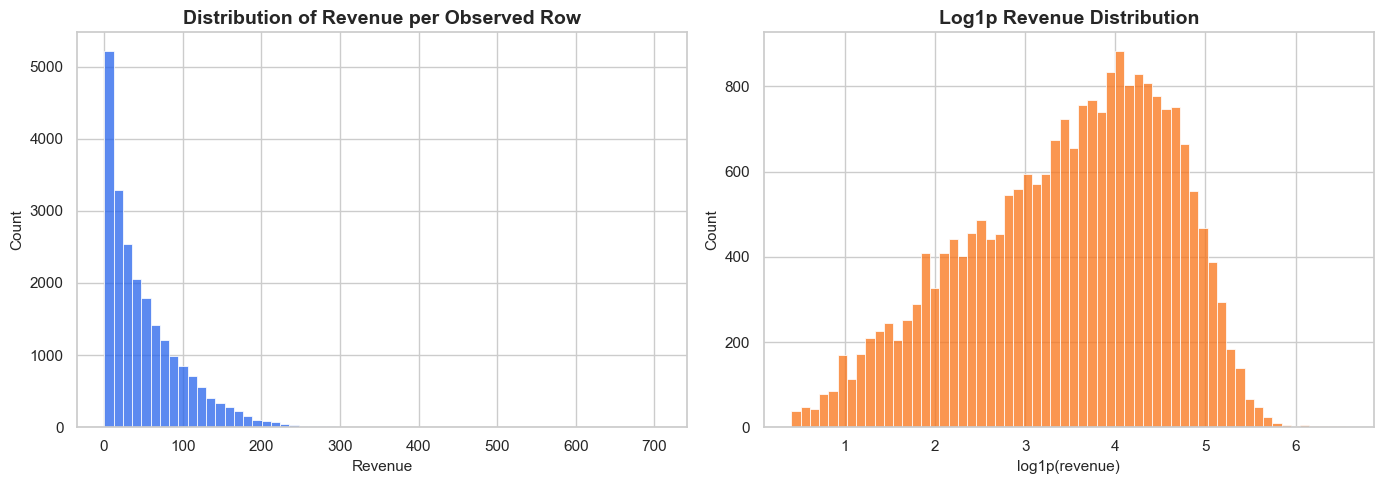

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["revenue"], bins=60, color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Distribution of Revenue per Observed Row")
axes[0].set_xlabel("Revenue")

sns.histplot(np.log1p(df["revenue"]), bins=60, color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title("Log1p Revenue Distribution")
axes[1].set_xlabel("log1p(revenue)")

plt.tight_layout()
plt.show()


**Insight chất lượng dữ liệu**

Dữ liệu sạch ở mức kỹ thuật: không có missing value, không có duplicate key, không có doanh thu âm. Tuy nhiên phân phối doanh thu lệch phải rõ rệt: phần lớn dòng có doanh thu nhỏ/trung bình, nhưng một số dòng như `Produce & Nuts` tại store lớn có doanh thu rất cao. Vì vậy khi modeling nên đánh giá bằng MAE/WAPE bên cạnh RMSE; RMSE sẽ phạt mạnh các đỉnh doanh thu lớn.


## 6. Phân Tích Độ Phủ Và Tính Ngắt Quãng Của Dữ Liệu


In [6]:
calendar_days = (df["transaction_date"].max() - df["transaction_date"].min()).days + 1
unique_global_dates = df["transaction_date"].nunique()

store_coverage = (
    df.groupby("store_id")
      .agg(
          first_date=("transaction_date", "min"),
          last_date=("transaction_date", "max"),
          unique_dates=("transaction_date", "nunique"),
          rows=("revenue", "size"),
          product_types=("product_type", "nunique"),
          total_revenue=("revenue", "sum"),
          city=("store_city", "first"),
          state=("store_state", "first"),
          store_type=("store_type", "first"),
          sales_region=("sales_region", "first"),
      )
      .reset_index()
)
store_coverage["span_days"] = (store_coverage["last_date"] - store_coverage["first_date"]).dt.days + 1
store_coverage["coverage_global"] = store_coverage["unique_dates"] / calendar_days
store_coverage["coverage_own_span"] = store_coverage["unique_dates"] / store_coverage["span_days"]

print("Calendar days in full date range:", calendar_days)
print("Unique dates appearing anywhere:", unique_global_dates)
print("Observed store-days:", df[["store_id", "transaction_date"]].drop_duplicates().shape[0])

display(
    store_coverage[[
        "store_id", "city", "state", "store_type", "sales_region", "first_date", "last_date",
        "unique_dates", "span_days", "coverage_global", "rows", "product_types", "total_revenue",
    ]].sort_values("store_id").round({"coverage_global": 3, "total_revenue": 2})
)


Calendar days in full date range: 729
Unique dates appearing anywhere: 649
Observed store-days: 1560


,store_id,city,state,store_type,sales_region,first_date,last_date,unique_dates,span_days,coverage_global,rows,product_types,total_revenue
0,2,Bellingham,WA,Small Grocery,North West,1997-01-05,1998-12-25,120,720,0.1650,1283,16,"9,519.1300"
1,3,Bremerton,WA,Supermarket,North West,1997-01-06,1998-12-25,120,719,0.1650,1863,16,"110,877.8800"
2,6,Beverly Hills,CA,Gourmet Supermarket,South West,1997-01-01,1998-12-28,120,727,0.1650,1861,16,"98,114.7800"
3,7,Los Angeles,CA,Supermarket,South West,1997-01-03,1998-12-20,120,717,0.1650,1899,16,"111,309.1400"
4,11,Portland,OR,Supermarket,North West,1997-01-02,1998-12-30,120,728,0.1650,1883,16,"115,334.6200"
5,13,Salem,OR,Deluxe Supermarket,North West,1997-01-07,1998-12-27,120,720,0.1650,1893,16,"170,398.9400"
6,14,San Francisco,CA,Small Grocery,Central West,1997-01-01,1998-12-29,120,728,0.1650,1282,16,"9,324.9400"
7,15,Seattle,WA,Supermarket,North West,1997-01-05,1998-12-16,120,711,0.1650,1881,16,"115,981.4600"
8,16,Spokane,WA,Supermarket,North West,1997-01-13,1998-12-27,120,714,0.1650,1870,16,"110,480.0600"
9,17,Tacoma,WA,Deluxe Supermarket,North West,1997-01-11,1998-12-29,120,718,0.1650,1900,16,"157,695.9000"


month_period,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06,1998-07,1998-08,1998-09,1998-10,1998-11,1998-12
store_id,,,,,,,,,,,,,,,,,,,,,,,,
2,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
3,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
6,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
7,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
11,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
13,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
14,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
15,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
16,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


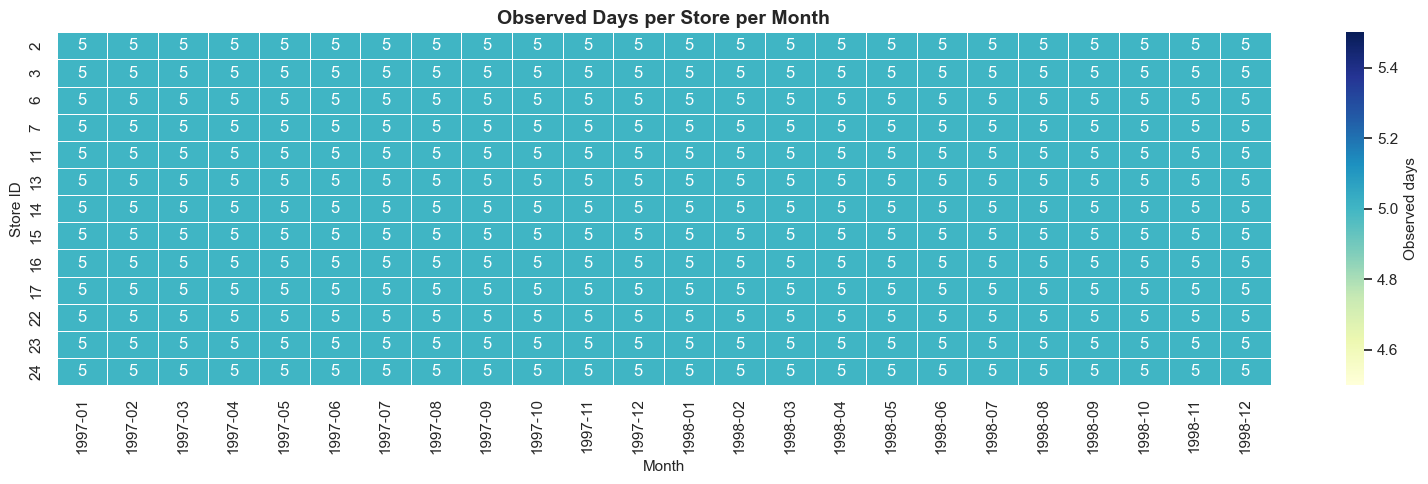

In [7]:
store_days_by_month = (
    df[["store_id", "transaction_date"]]
    .drop_duplicates()
    .assign(month_period=lambda x: x["transaction_date"].dt.to_period("M").astype(str))
    .groupby(["store_id", "month_period"])
    .size()
    .unstack(fill_value=0)
)

display(store_days_by_month)

plt.figure(figsize=(16, 5))
sns.heatmap(
    store_days_by_month,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={"label": "Observed days"},
    linewidths=0.4,
)
plt.title("Observed Days per Store per Month")
plt.xlabel("Month")
plt.ylabel("Store ID")
plt.tight_layout()
plt.show()


,n_calendar_days
observed_stores,
0,80
1,174
2,203
3,154
4,76
5,38
6,4


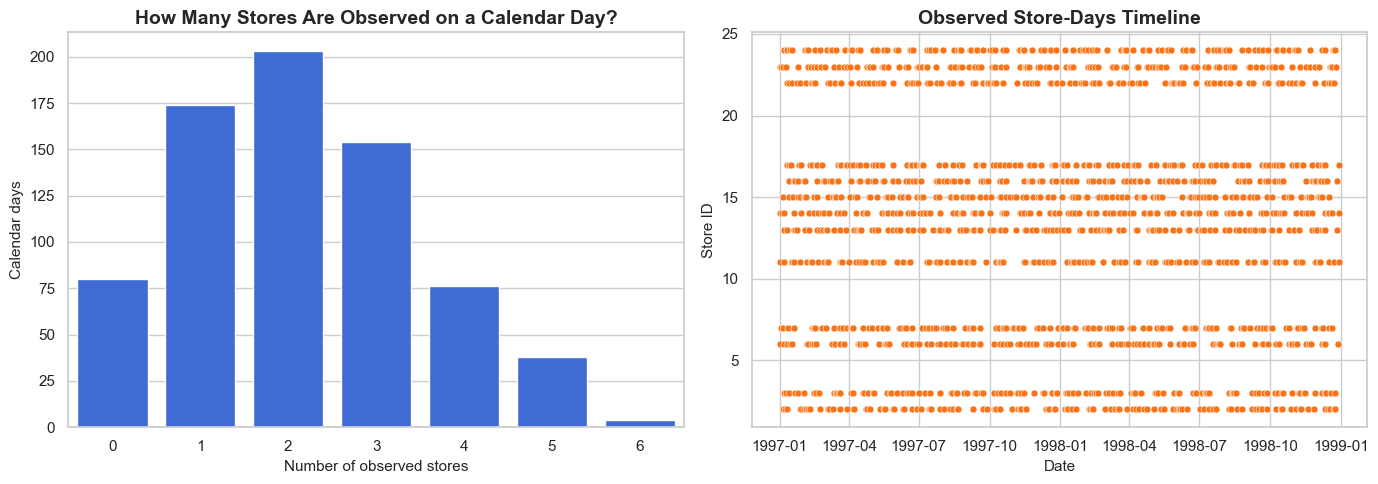

In [8]:
all_dates = pd.DataFrame({"transaction_date": pd.date_range(df["transaction_date"].min(), df["transaction_date"].max(), freq="D")})
observed_store_count = (
    df[["transaction_date", "store_id"]]
    .drop_duplicates()
    .groupby("transaction_date")
    .size()
    .rename("observed_stores")
    .reset_index()
)
date_coverage = all_dates.merge(observed_store_count, on="transaction_date", how="left").fillna({"observed_stores": 0})
date_coverage["observed_stores"] = date_coverage["observed_stores"].astype(int)

display(date_coverage["observed_stores"].value_counts().sort_index().rename_axis("observed_stores").to_frame("n_calendar_days"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=date_coverage, x="observed_stores", color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("How Many Stores Are Observed on a Calendar Day?")
axes[0].set_xlabel("Number of observed stores")
axes[0].set_ylabel("Calendar days")

sns.scatterplot(
    data=df[["store_id", "transaction_date"]].drop_duplicates(),
    x="transaction_date",
    y="store_id",
    s=25,
    color=COLOR_ACCENT,
    ax=axes[1],
)
axes[1].set_title("Observed Store-Days Timeline")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Store ID")

plt.tight_layout()
plt.show()


**Insight độ phủ**

Đây là phát hiện quan trọng nhất của dataset: mỗi store có đúng 120 ngày dữ liệu, tương ứng `5 ngày/tháng × 24 tháng`. Các ngày không có record là ngày không được lấy mẫu, không phải ngày doanh thu bằng 0. Vì vậy mô hình daily forecast không nên tạo full calendar và fill 0 cho toàn bộ ngày thiếu.

Ở cấp toàn hệ thống, mỗi ngày lịch có số store được quan sát khác nhau, nhiều ngày chỉ có 1-3 store. Do đó tổng doanh thu theo ngày toàn hệ thống bị ảnh hưởng mạnh bởi số store được lấy mẫu trong ngày đó.


## 7. Xử Lý Product Type Thiếu Trong Store-Day Đã Quan Sát


In [9]:
def build_observed_store_product_panel(source_df):
    """Create store-date-product panel only for store-days that exist in the dataset.

    We do not create unobserved calendar store-days.
    For an observed store-day, missing product_type rows are treated as zero revenue.
    """
    store_day_cols = [
        "transaction_date", "store_id", "region_id", "store_type", "store_city", "store_state",
        "first_opened_date", "last_remodel_date", "total_sqft", "grocery_sqft", "sales_district", "sales_region",
        "weather_code", "temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh",
        "shortwave_radiation_mj_m2", "year", "month", "quarter", "day", "day_of_week", "day_of_week_num",
        "week_of_year", "is_weekend", "store_age_years", "years_since_remodel", "grocery_sqft_ratio",
        "is_rainy_day", "is_snowy_day", "is_windy_day",
    ]
    store_day = source_df[store_day_cols].drop_duplicates(["store_id", "transaction_date"]).copy()
    product_types = pd.DataFrame({"product_type": sorted(source_df["product_type"].unique())})

    panel = (
        store_day.assign(_key=1)
        .merge(product_types.assign(_key=1), on="_key")
        .drop(columns="_key")
        .merge(
            source_df[["transaction_date", "store_id", "product_type", "revenue"]],
            on=["transaction_date", "store_id", "product_type"],
            how="left",
        )
    )
    panel["had_observed_transaction_row"] = panel["revenue"].notna().astype(int)
    panel["revenue"] = panel["revenue"].fillna(0.0)
    panel = panel.sort_values(["store_id", "product_type", "transaction_date"]).reset_index(drop=True)
    return panel

panel = build_observed_store_product_panel(df)

print("Original rows:", len(df))
print("Panel rows after adding zero product rows within observed store-days:", len(panel))
print("Added zero rows:", len(panel) - len(df))
print("Observed store-days:", panel[["store_id", "transaction_date"]].drop_duplicates().shape[0])
print("Expected rows = observed store-days × product types:", panel[["store_id", "transaction_date"]].drop_duplicates().shape[0] * df["product_type"].nunique())

show_df(panel, 5)


Original rows: 22476
Panel rows after adding zero product rows within observed store-days: 24960
Added zero rows: 2484
Observed store-days: 1560
Expected rows = observed store-days × product types: 24960


,transaction_date,store_id,region_id,store_type,store_city,store_state,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,weather_code,temperature_mean_c,precipitation_mm,snowfall_cm,wind_speed_max_kmh,shortwave_radiation_mj_m2,year,month,quarter,day,day_of_week,day_of_week_num,week_of_year,is_weekend,store_age_years,years_since_remodel,grocery_sqft_ratio,is_rainy_day,is_snowy_day,is_windy_day,product_type,revenue,had_observed_transaction_row
0,1997-01-05,2,78,Small Grocery,Bellingham,WA,1970-04-02,1973-06-04,28206,22271,Bellingham,North West,3,1.5000,0.0000,0.0000,18.7000,3.5400,1997,1,1,5,Sunday,6,1,1,26.7625,23.5893,0.7896,0,0,0,Alcohol,0.0000,0
1,1997-01-08,2,78,Small Grocery,Bellingham,WA,1970-04-02,1973-06-04,28206,22271,Bellingham,North West,51,5.5000,1.9000,0.0000,10.8000,2.0000,1997,1,1,8,Wednesday,2,2,0,26.7707,23.5975,0.7896,1,0,0,Alcohol,0.0000,0
2,1997-01-10,2,78,Small Grocery,Bellingham,WA,1970-04-02,1973-06-04,28206,22271,Bellingham,North West,3,4.5000,0.0000,0.0000,4.7000,2.9800,1997,1,1,10,Friday,4,2,0,26.7762,23.6030,0.7896,0,0,0,Alcohol,7.5800,1
3,1997-01-28,2,78,Small Grocery,Bellingham,WA,1970-04-02,1973-06-04,28206,22271,Bellingham,North West,61,3.3000,3.8000,0.0000,18.3000,1.8000,1997,1,1,28,Tuesday,1,5,0,26.8255,23.6523,0.7896,1,0,0,Alcohol,0.0000,0
4,1997-01-29,2,78,Small Grocery,Bellingham,WA,1970-04-02,1973-06-04,28206,22271,Bellingham,North West,63,5.5000,19.9000,0.0000,27.8000,1.2400,1997,1,1,29,Wednesday,2,5,0,26.8282,23.6550,0.7896,1,0,0,Alcohol,0.0000,0


,product_type,expected_rows,positive_rows,zero_rows,zero_rate,total_revenue,mean_revenue_including_zero
3,Breakfast Foods,1560,1065,495,0.3170,"14,869.3400",9.5300
12,Pasta & Rice,1560,1220,340,0.2180,"24,362.9400",15.6200
9,Magazines & Miscellaneous,1560,1243,317,0.2030,"24,890.3500",15.9600
0,Alcohol,1560,1307,253,0.1620,"29,488.2800",18.9000
14,Seafood,1560,1308,252,0.1620,"33,452.3200",21.4400
1,Bakery,1560,1341,219,0.1400,"34,571.4800",22.1600
7,Health & Personal Care,1560,1455,105,0.0670,"61,821.1100",39.6300
4,Canned & Soup,1560,1458,102,0.0650,"62,534.7800",40.0900
10,Meat & Deli,1560,1465,95,0.0610,"64,749.3800",41.5100
2,Beverages,1560,1484,76,0.0490,"78,394.2800",50.2500


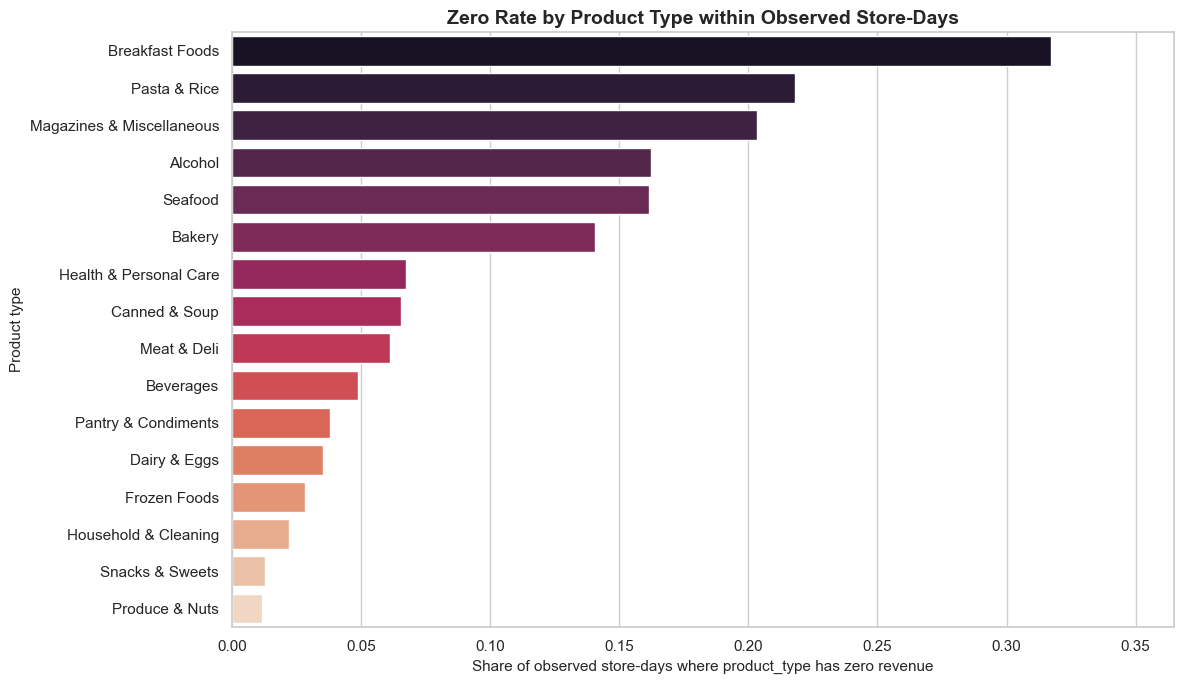

In [10]:
missing_product = (
    panel.groupby("product_type")
    .agg(
        expected_rows=("revenue", "size"),
        positive_rows=("had_observed_transaction_row", "sum"),
        zero_rows=("had_observed_transaction_row", lambda s: (s == 0).sum()),
        zero_rate=("had_observed_transaction_row", lambda s: (s == 0).mean()),
        total_revenue=("revenue", "sum"),
        mean_revenue_including_zero=("revenue", "mean"),
    )
    .reset_index()
    .sort_values("zero_rate", ascending=False)
)

display(missing_product.round({"zero_rate": 3, "total_revenue": 2, "mean_revenue_including_zero": 2}))

plt.figure(figsize=(12, 7))
sns.barplot(data=missing_product, y="product_type", x="zero_rate", palette="rocket")
plt.title("Zero Rate by Product Type within Observed Store-Days")
plt.xlabel("Share of observed store-days where product_type has zero revenue")
plt.ylabel("Product type")
plt.xlim(0, missing_product["zero_rate"].max() * 1.15)
plt.tight_layout()
plt.show()


**Insight product-type zero**

Trong một `store_id × date` đã được quan sát, nếu một `product_type` không xuất hiện thì có thể hiểu hợp lý là nhóm đó không có doanh thu trong ngày được lấy mẫu. Vì vậy notebook tạo panel đầy đủ theo `observed store-day × 16 product types` và fill các dòng thiếu bằng 0.

Các nhóm như `Breakfast Foods`, `Pasta & Rice`, `Magazines & Miscellaneous`, `Alcohol`, `Seafood` có zero-rate cao hơn. Điều này quan trọng cho model: model cần học cả khả năng doanh thu thấp/0, không chỉ học trên các dòng positive revenue.


## 8. EDA Doanh Thu Theo Product Type Và Store


,product_type,total_revenue,mean_revenue,median_revenue,positive_rate,revenue_share
13,Produce & Nuts,"169,819.1600",108.8600,112.8600,0.9880,0.1440
15,Snacks & Sweets,"151,010.6500",96.8000,100.4800,0.9870,0.1280
8,Household & Cleaning,"137,072.2200",87.8700,89.6000,0.9780,0.1160
6,Frozen Foods,"115,666.2900",74.1500,74.9700,0.9720,0.0980
5,Dairy & Eggs,"93,070.2100",59.6600,57.7600,0.9650,0.0790
11,Pantry & Condiments,"82,176.1500",52.6800,51.2200,0.9620,0.0700
2,Beverages,"78,394.2800",50.2500,49.0600,0.9510,0.0670
10,Meat & Deli,"64,749.3800",41.5100,38.8500,0.9390,0.0550
4,Canned & Soup,"62,534.7800",40.0900,39.1400,0.9350,0.0530
7,Health & Personal Care,"61,821.1100",39.6300,37.4500,0.9330,0.0520


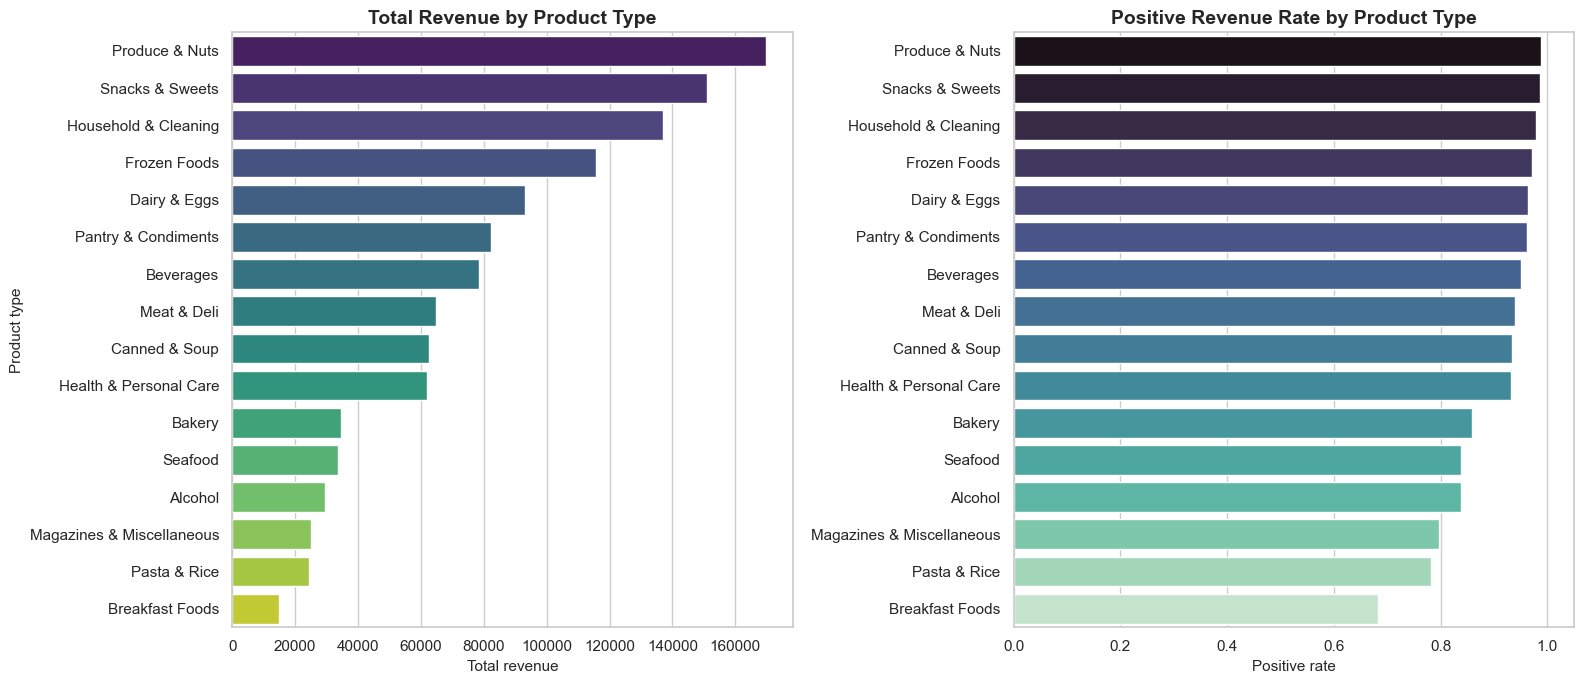

In [11]:
product_summary = (
    panel.groupby("product_type")
    .agg(
        total_revenue=("revenue", "sum"),
        mean_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        positive_rate=("had_observed_transaction_row", "mean"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
product_summary["revenue_share"] = product_summary["total_revenue"] / product_summary["total_revenue"].sum()

display(product_summary.round({"total_revenue": 2, "mean_revenue": 2, "median_revenue": 2, "positive_rate": 3, "revenue_share": 3}))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=product_summary, y="product_type", x="total_revenue", palette="viridis", ax=axes[0])
axes[0].set_title("Total Revenue by Product Type")
axes[0].set_xlabel("Total revenue")
axes[0].set_ylabel("Product type")

sns.barplot(data=product_summary, y="product_type", x="positive_rate", palette="mako", ax=axes[1])
axes[1].set_title("Positive Revenue Rate by Product Type")
axes[1].set_xlabel("Positive rate")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()


,store_id,store_city,store_state,store_type,sales_region,total_revenue,mean_revenue,positive_rate,total_sqft,grocery_sqft
5,13,Salem,OR,Deluxe Supermarket,North West,"170,398.9400",88.7500,0.9860,27694,18670
9,17,Tacoma,WA,Deluxe Supermarket,North West,"157,695.9000",82.1300,0.9900,33858,22123
7,15,Seattle,WA,Supermarket,North West,"115,981.4600",60.4100,0.9800,21215,13305
4,11,Portland,OR,Supermarket,North West,"115,334.6200",60.0700,0.9810,20319,16232
12,24,San Diego,CA,Supermarket,South West,"111,378.4600",58.0100,0.9750,27372,18293
3,7,Los Angeles,CA,Supermarket,South West,"111,309.1400",57.9700,0.9890,23598,14210
1,3,Bremerton,WA,Supermarket,North West,"110,877.8800",57.7500,0.9700,39696,24390
8,16,Spokane,WA,Supermarket,North West,"110,480.0600",57.5400,0.9740,30268,22063
2,6,Beverly Hills,CA,Gourmet Supermarket,South West,"98,114.7800",51.1000,0.9690,23688,15337
11,23,Yakima,WA,Mid-Size Grocery,North West,"47,576.7800",24.7800,0.8850,29182,19283


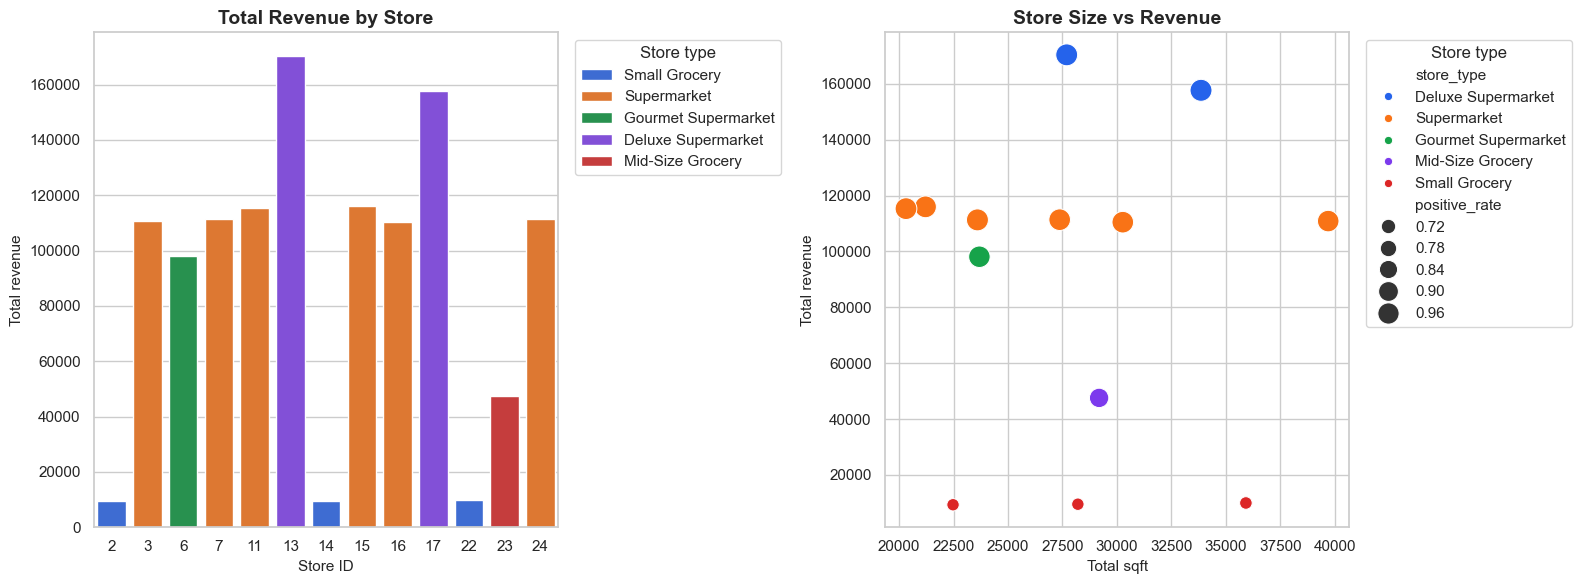

In [12]:
store_summary = (
    panel.groupby(["store_id", "store_city", "store_state", "store_type", "sales_region"])
    .agg(
        total_revenue=("revenue", "sum"),
        mean_revenue=("revenue", "mean"),
        positive_rate=("had_observed_transaction_row", "mean"),
        total_sqft=("total_sqft", "first"),
        grocery_sqft=("grocery_sqft", "first"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

display(store_summary.round({"total_revenue": 2, "mean_revenue": 2, "positive_rate": 3}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=store_summary, x="store_id", y="total_revenue", hue="store_type", dodge=False, palette=PALETTE_CONTRAST, ax=axes[0])
axes[0].set_title("Total Revenue by Store")
axes[0].set_xlabel("Store ID")
axes[0].set_ylabel("Total revenue")
axes[0].legend(title="Store type", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=store_summary,
    x="total_sqft",
    y="total_revenue",
    hue="store_type",
    size="positive_rate",
    sizes=(80, 250),
    palette=PALETTE_CONTRAST,
    ax=axes[1],
)
axes[1].set_title("Store Size vs Revenue")
axes[1].set_xlabel("Total sqft")
axes[1].set_ylabel("Total revenue")
axes[1].legend(title="Store type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


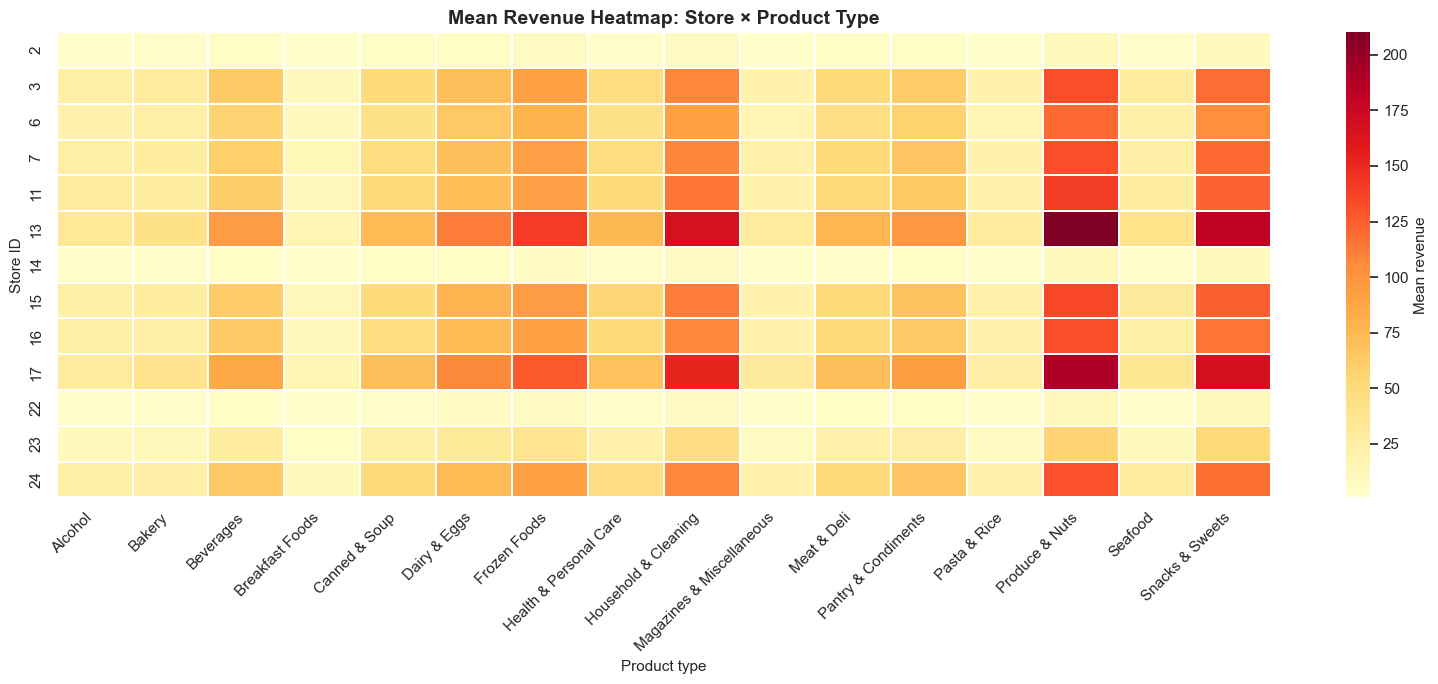

In [13]:
store_product_heatmap = (
    panel.groupby(["store_id", "product_type"])["revenue"]
    .mean()
    .unstack("product_type")
)

plt.figure(figsize=(16, 7))
sns.heatmap(store_product_heatmap, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Mean revenue"})
plt.title("Mean Revenue Heatmap: Store × Product Type")
plt.xlabel("Product type")
plt.ylabel("Store ID")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Insight product/store**

Doanh thu tập trung mạnh ở một số product type: `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`, `Frozen Foods`. Ở chiều store, các `Deluxe Supermarket` và `Supermarket` lớn tạo doanh thu vượt trội, trong khi `Small Grocery` vừa có tổng doanh thu thấp vừa có tỷ lệ product-type positive thấp hơn.

Heatmap `store × product_type` cho thấy baseline theo cặp store-product rất mạnh. Đây là lý do model nên có feature/cấu trúc ghi nhớ mức nền của từng cặp `store_id × product_type`.


## 9. EDA Mùa Vụ, Tháng Và Ngày Trong Tuần


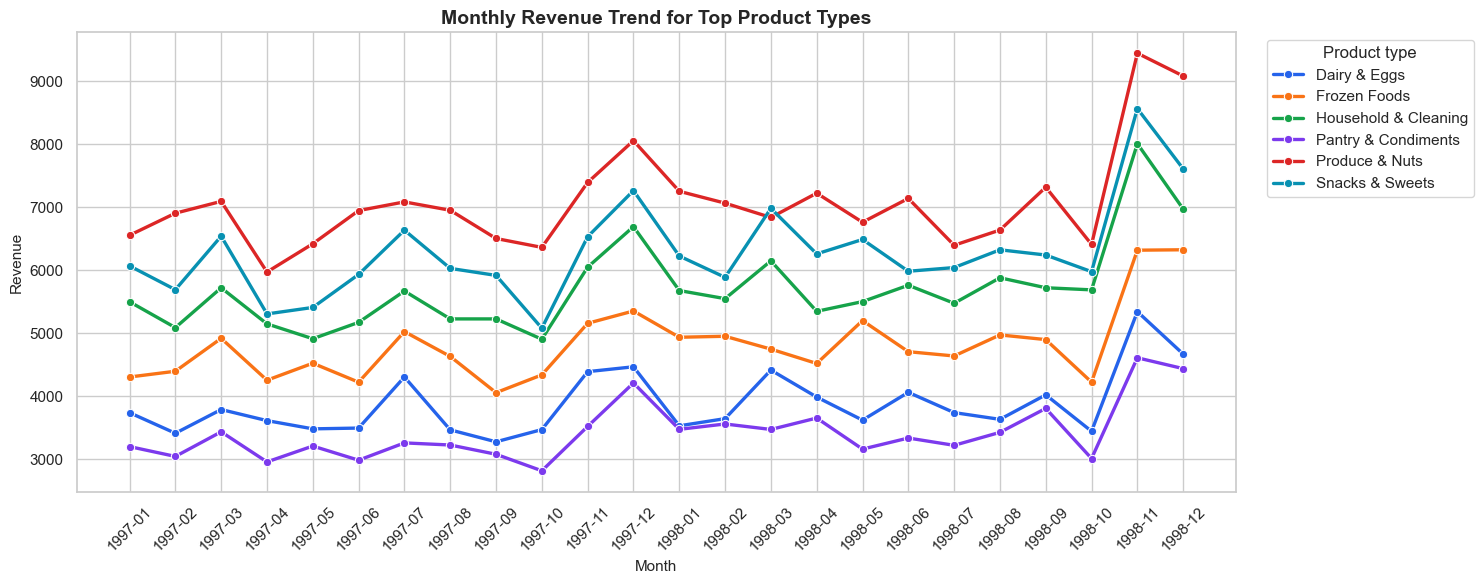

In [14]:
monthly_product = (
    panel.groupby([panel["transaction_date"].dt.to_period("M").astype(str), "product_type"])
    .agg(revenue=("revenue", "sum"))
    .reset_index()
    .rename(columns={"transaction_date": "month_period"})
)

top_products = product_summary.head(6)["product_type"].tolist()
monthly_top = monthly_product[monthly_product["product_type"].isin(top_products)].copy()

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_top, x="month_period", y="revenue", hue="product_type", marker="o", linewidth=2.4, palette=PALETTE_CONTRAST)
plt.title("Monthly Revenue Trend for Top Product Types")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Product type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


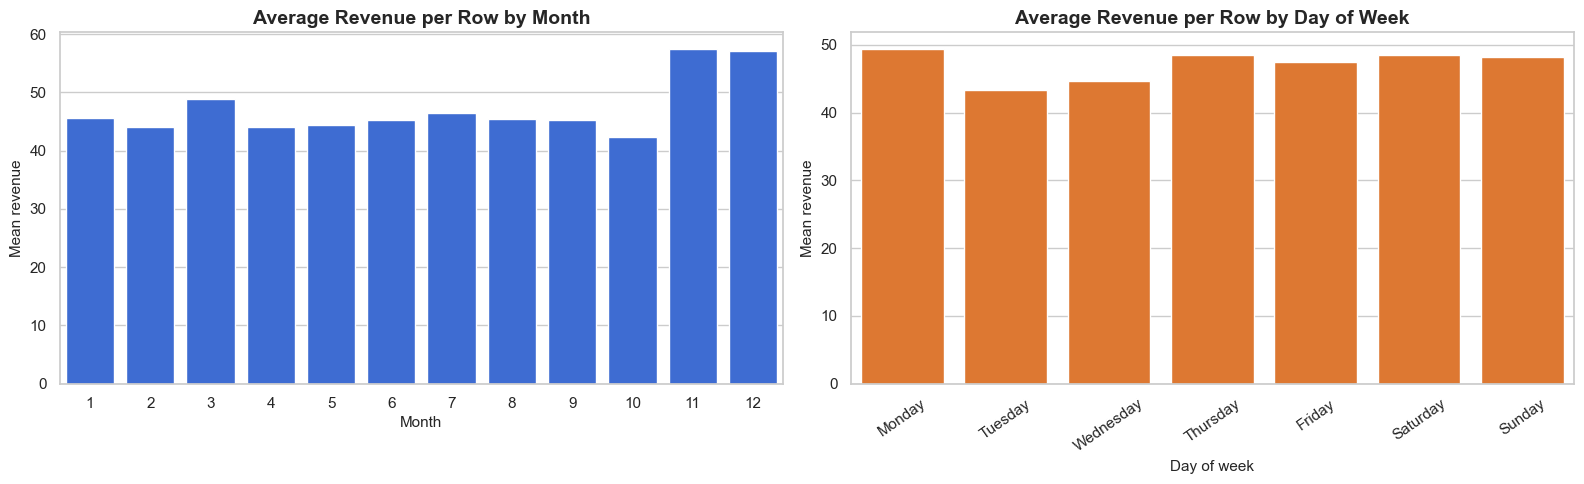

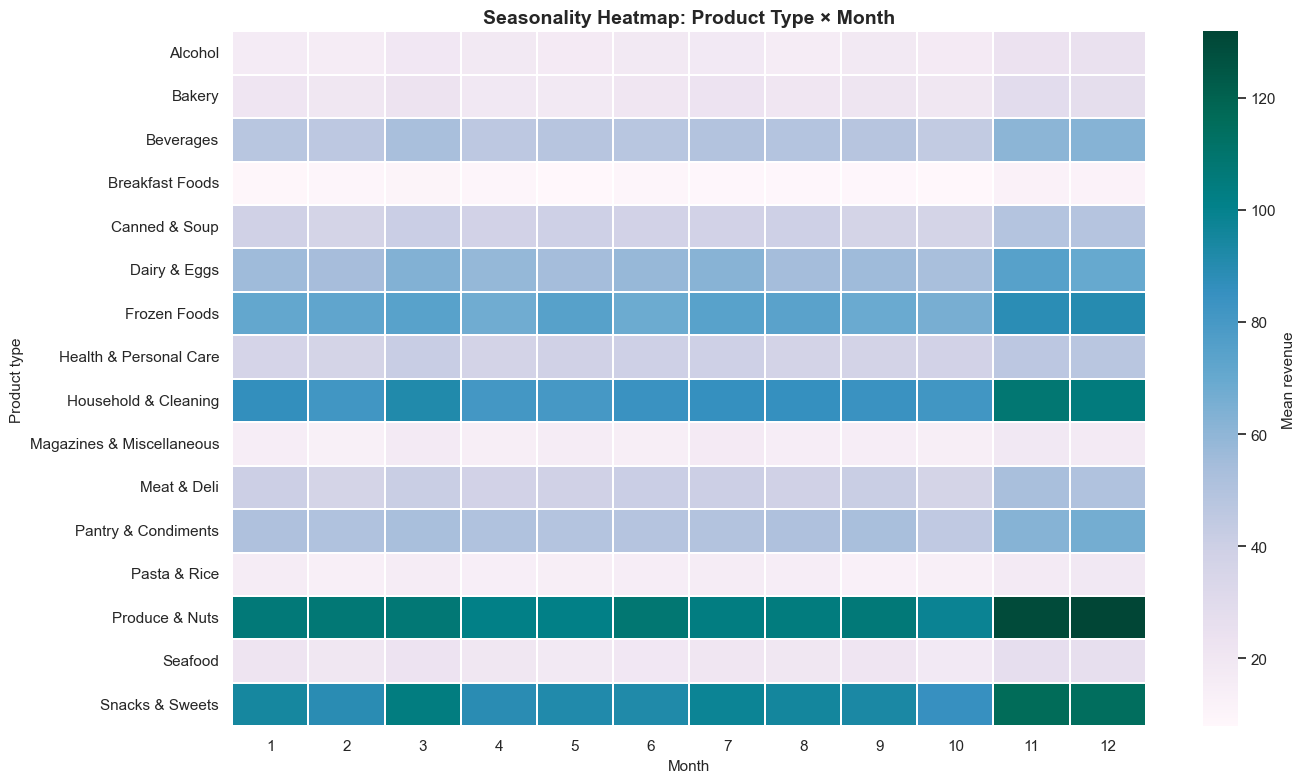

In [15]:
month_summary = (
    panel.groupby("month")
    .agg(total_revenue=("revenue", "sum"), mean_revenue=("revenue", "mean"))
    .reset_index()
)

dow_summary = (
    panel.groupby(["day_of_week_num", "day_of_week"])
    .agg(total_revenue=("revenue", "sum"), mean_revenue=("revenue", "mean"))
    .reset_index()
    .sort_values("day_of_week_num")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=month_summary, x="month", y="mean_revenue", color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Average Revenue per Row by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean revenue")

sns.barplot(data=dow_summary, x="day_of_week", y="mean_revenue", color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title("Average Revenue per Row by Day of Week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Mean revenue")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

product_month_heatmap = panel.groupby(["product_type", "month"])["revenue"].mean().unstack("month")
plt.figure(figsize=(14, 8))
sns.heatmap(product_month_heatmap, cmap="PuBuGn", linewidths=0.3, cbar_kws={"label": "Mean revenue"})
plt.title("Seasonality Heatmap: Product Type × Month")
plt.xlabel("Month")
plt.ylabel("Product type")
plt.tight_layout()
plt.show()


**Insight mùa vụ**

Vì mỗi tháng có đúng 65 observed store-days (`13 stores × 5 ngày`), tổng doanh thu theo tháng tương đối công bằng hơn daily aggregate. Pattern mùa vụ nổi bật nhất là doanh thu tăng ở cuối năm, đặc biệt tháng 11-12. Điều này phù hợp với hành vi retail dịp lễ/cuối năm.

Ngày trong tuần có khác biệt nhưng không mạnh bằng store/product baseline và month seasonality. Vì vậy model nên dùng month/quarter/cyclic calendar, còn day-of-week là feature phụ.


## 10. Weather EDA: Có Tín Hiệu Nhưng Không Nên Phụ Thuộc Quá Mạnh


,daily_revenue
shortwave_radiation_mj_m2,-0.1070
precipitation_mm,0.0580
snowfall_cm,-0.0212
temperature_mean_c,-0.0189
wind_speed_max_kmh,-0.0010


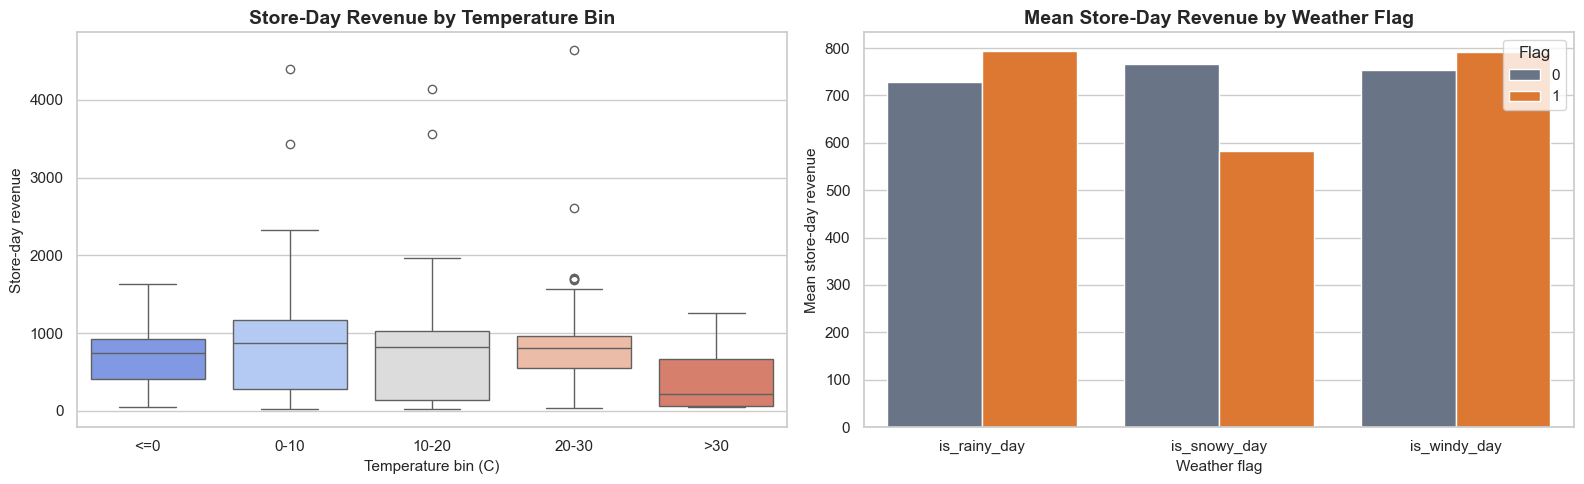

In [16]:
# Weather analysis should be done at store-day level to avoid repeating the same weather 16 times per product type.
store_day_revenue = (
    panel.groupby(["store_id", "transaction_date"])
    .agg(
        daily_revenue=("revenue", "sum"),
        product_types_positive=("had_observed_transaction_row", "sum"),
        store_type=("store_type", "first"),
        sales_region=("sales_region", "first"),
        weather_code=("weather_code", "first"),
        temperature_mean_c=("temperature_mean_c", "first"),
        precipitation_mm=("precipitation_mm", "first"),
        snowfall_cm=("snowfall_cm", "first"),
        wind_speed_max_kmh=("wind_speed_max_kmh", "first"),
        shortwave_radiation_mj_m2=("shortwave_radiation_mj_m2", "first"),
        is_rainy_day=("is_rainy_day", "first"),
        is_snowy_day=("is_snowy_day", "first"),
        is_windy_day=("is_windy_day", "first"),
        month=("month", "first"),
    )
    .reset_index()
)

weather_numeric = ["temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh", "shortwave_radiation_mj_m2"]
weather_corr = store_day_revenue[weather_numeric + ["daily_revenue"]].corr()[["daily_revenue"]].drop("daily_revenue").sort_values("daily_revenue", key=lambda s: s.abs(), ascending=False)
display(weather_corr.round(4))

store_day_revenue["temp_bin"] = pd.cut(
    store_day_revenue["temperature_mean_c"],
    bins=[-20, 0, 10, 20, 30, 45],
    labels=["<=0", "0-10", "10-20", "20-30", ">30"],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=store_day_revenue, x="temp_bin", y="daily_revenue", palette="coolwarm", ax=axes[0])
axes[0].set_title("Store-Day Revenue by Temperature Bin")
axes[0].set_xlabel("Temperature bin (C)")
axes[0].set_ylabel("Store-day revenue")

weather_flag_summary = (
    store_day_revenue.melt(
        id_vars=["daily_revenue"],
        value_vars=["is_rainy_day", "is_snowy_day", "is_windy_day"],
        var_name="weather_flag",
        value_name="flag",
    )
    .groupby(["weather_flag", "flag"])
    .agg(mean_revenue=("daily_revenue", "mean"), n=("daily_revenue", "size"))
    .reset_index()
)
sns.barplot(data=weather_flag_summary, x="weather_flag", y="mean_revenue", hue="flag", palette=[COLOR_GRAY, COLOR_ACCENT], ax=axes[1])
axes[1].set_title("Mean Store-Day Revenue by Weather Flag")
axes[1].set_xlabel("Weather flag")
axes[1].set_ylabel("Mean store-day revenue")
axes[1].legend(title="Flag")

plt.tight_layout()
plt.show()


**Insight weather**

Weather có thể có một số tương quan với doanh thu store-day, nhưng tín hiệu không mạnh và dễ bị nhiễu bởi store/product mix. Ngoài ra, nếu dùng weather cho dự báo tương lai thì cần forecast thời tiết cho từng store/date. Vì mục tiêu notebook là tạo pipeline forecast thực dụng từ dataset hiện có, model cuối sẽ không phụ thuộc weather. Weather vẫn có thể là extension sau nếu bạn có dữ liệu forecast thời tiết.


## 11. Deep Data Understanding Và Kiểm Định Insight Theo `product_type`

Phần này đào sâu hơn vào bản chất riêng của Maven. Ở bài toán này, `product_type` là nhóm sản phẩm chính cần dự báo. Vì dataset không phải daily panel đầy đủ mà là `5 observed store-days / tháng / store`, mọi kết luận cần được hiểu trong phạm vi các ngày được lấy mẫu.

Để so sánh pattern giữa sản phẩm/store công bằng hơn, ta dùng thêm:

```text
revenue_index = revenue / baseline(store_id × product_type × year)
```

Baseline ưu tiên median của cùng `store_id × product_type × year`; nếu median bằng 0 thì fallback sang mean. Chỉ số này giúp kiểm tra seasonality, weekend, weather mà không bị scale rất lớn của `Produce & Nuts` hoặc store `Deluxe Supermarket` lấn át.


In [17]:
eda_df = panel.copy()

base_revenue = eda_df.groupby(["store_id", "product_type", "year"])["revenue"].transform("median")
mean_base_revenue = eda_df.groupby(["store_id", "product_type", "year"])["revenue"].transform("mean")
product_year_base = eda_df.groupby(["product_type", "year"])["revenue"].transform("median")

base_revenue = (
    base_revenue
    .mask(base_revenue <= 0, mean_base_revenue)
    .mask(lambda s: s <= 0, product_year_base)
    .replace(0, np.nan)
)

eda_df["revenue_index"] = eda_df["revenue"] / base_revenue
eda_df["is_q4"] = eda_df["month"].isin([10, 11, 12]).astype(int)
eda_df["split"] = np.where(eda_df["transaction_date"] < pd.Timestamp("1998-07-01"), "train", "test")

# Helper: approximate CI for normalized mean difference by product type.
def mean_diff_ci_by_product(data, group_col, positive_value=1):
    rows = []
    for product_type, sub in data.groupby("product_type"):
        # Aggregate by date and flag to reduce repeated store rows.
        date_level = (
            sub.groupby(["transaction_date", group_col])["revenue_index"]
            .mean()
            .reset_index()
        )
        a = date_level.loc[date_level[group_col] == positive_value, "revenue_index"].dropna().values
        b = date_level.loc[date_level[group_col] != positive_value, "revenue_index"].dropna().values
        diff = a.mean() - b.mean()
        se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
        rows.append({
            "product_type": product_type,
            "n_positive_groups": len(a),
            "n_other_groups": len(b),
            "mean_positive": a.mean(),
            "mean_other": b.mean(),
            "diff_index": diff,
            "ci_low": diff - 1.96 * se,
            "ci_high": diff + 1.96 * se,
            "lift_pct": (a.mean() / b.mean() - 1) * 100,
        })
    return pd.DataFrame(rows)

print("Revenue index sanity check:")
display(eda_df[["revenue", "revenue_index"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.round(3))
print("Revenue index missing:", eda_df["revenue_index"].isna().sum())


Revenue index sanity check:


,count,mean,std,min,1%,5%,50%,95%,99%,max
revenue,"24,960.0000",47.1930,51.2380,0.0000,0.0000,0.0000,30.3700,148.2500,213.9490,706.4500
revenue_index,"24,960.0000",1.1070,0.9200,0.0000,0.0000,0.0000,0.9870,2.5790,4.5950,17.5090


Revenue index missing: 0


### 11.1. Product Type Profile: Scale, Zero Rate, Volatility

Câu hỏi: nhóm sản phẩm nào chi phối doanh thu, nhóm nào sparse/long-tail, nhóm nào biến động mạnh?


,product_type,rows,total_revenue,mean_revenue,median_revenue,std_revenue,zero_rate,positive_rate,revenue_share,cv
13,Produce & Nuts,1560,"169,819.1600",108.8600,112.8600,77.5800,0.0120,0.9880,0.1440,0.7100
15,Snacks & Sweets,1560,"151,010.6500",96.8000,100.4800,68.1800,0.0130,0.9870,0.1280,0.7000
8,Household & Cleaning,1560,"137,072.2200",87.8700,89.6000,64.2500,0.0220,0.9780,0.1160,0.7300
6,Frozen Foods,1560,"115,666.2900",74.1500,74.9700,55.3000,0.0280,0.9720,0.0980,0.7500
5,Dairy & Eggs,1560,"93,070.2100",59.6600,57.7600,45.7100,0.0350,0.9650,0.0790,0.7700
11,Pantry & Condiments,1560,"82,176.1500",52.6800,51.2200,39.2200,0.0380,0.9620,0.0700,0.7400
2,Beverages,1560,"78,394.2800",50.2500,49.0600,38.2800,0.0490,0.9510,0.0670,0.7600
10,Meat & Deli,1560,"64,749.3800",41.5100,38.8500,31.9000,0.0610,0.9390,0.0550,0.7700
4,Canned & Soup,1560,"62,534.7800",40.0900,39.1400,31.0400,0.0650,0.9350,0.0530,0.7700
7,Health & Personal Care,1560,"61,821.1100",39.6300,37.4500,31.3500,0.0670,0.9330,0.0520,0.7900


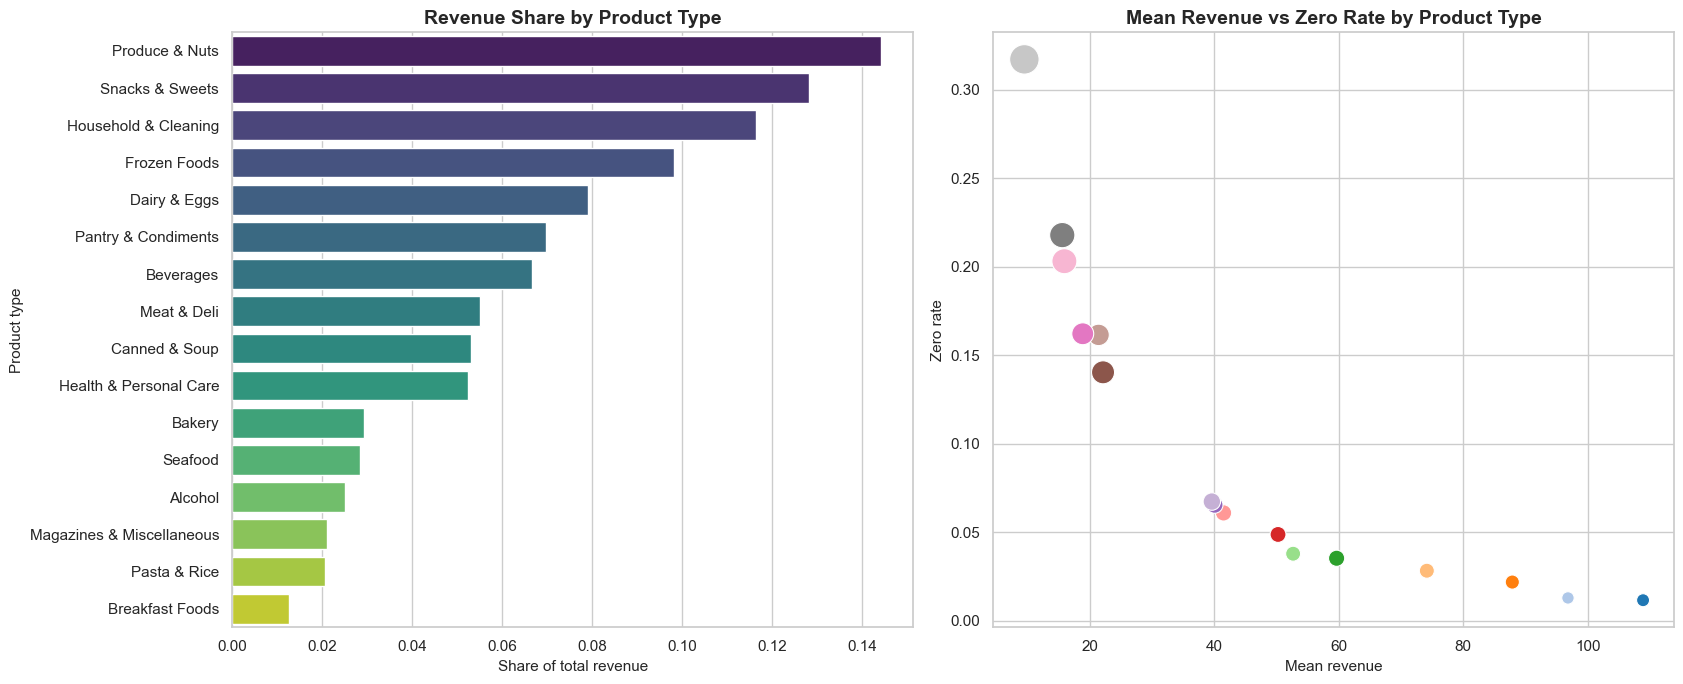

In [18]:
product_deep_profile = (
    eda_df.groupby("product_type")
    .agg(
        rows=("revenue", "size"),
        total_revenue=("revenue", "sum"),
        mean_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        std_revenue=("revenue", "std"),
        zero_rate=("revenue", lambda s: (s == 0).mean()),
        positive_rate=("had_observed_transaction_row", "mean"),
    )
    .reset_index()
)
product_deep_profile["revenue_share"] = product_deep_profile["total_revenue"] / product_deep_profile["total_revenue"].sum()
product_deep_profile["cv"] = product_deep_profile["std_revenue"] / product_deep_profile["mean_revenue"]
product_deep_profile = product_deep_profile.sort_values("total_revenue", ascending=False)

display(product_deep_profile.round({
    "total_revenue": 2, "mean_revenue": 2, "median_revenue": 2,
    "std_revenue": 2, "zero_rate": 3, "positive_rate": 3,
    "revenue_share": 3, "cv": 2,
}))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.barplot(data=product_deep_profile, y="product_type", x="revenue_share", palette="viridis", ax=axes[0])
axes[0].set_title("Revenue Share by Product Type")
axes[0].set_xlabel("Share of total revenue")
axes[0].set_ylabel("Product type")

sns.scatterplot(
    data=product_deep_profile,
    x="mean_revenue",
    y="zero_rate",
    size="cv",
    hue="product_type",
    sizes=(80, 450),
    palette="tab20",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Mean Revenue vs Zero Rate by Product Type")
axes[1].set_xlabel("Mean revenue")
axes[1].set_ylabel("Zero rate")

plt.tight_layout()
plt.show()


**Insight**

Doanh thu tập trung ở nhóm thiết yếu/volume cao như `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`, `Frozen Foods`. Ngược lại, `Breakfast Foods`, `Pasta & Rice`, `Magazines & Miscellaneous`, `Alcohol`, `Seafood` có zero-rate cao hơn và biến động tương đối lớn hơn.

Điều này ảnh hưởng trực tiếp đến modeling: một model global có thể dự báo tốt nhóm lớn nhưng vẫn sai đáng kể ở nhóm sparse. Vì vậy cần xem error theo `product_type`, không chỉ metric tổng.


### 11.2. Store Type Và Product Availability: Small Grocery Là Một Segment Rất Khác

Câu hỏi: zero revenue đến từ product demand hay từ format cửa hàng? Store type nào có product coverage yếu?


,store_type,stores,rows,total_revenue,mean_revenue,zero_rate,avg_sqft,avg_grocery_ratio
0,Deluxe Supermarket,2,3840,"328,094.8400",85.4400,0.0120,"30,776.0000",0.6640
4,Supermarket,6,11520,"675,361.6200",58.6300,0.0220,"27,078.0000",0.6730
1,Gourmet Supermarket,1,1920,"98,114.7800",51.1000,0.0310,"23,688.0000",0.6470
2,Mid-Size Grocery,1,1920,"47,576.7800",24.7800,0.1150,"29,182.0000",0.6610
3,Small Grocery,3,5760,"28,800.9200",5.0000,0.3310,"28,867.0000",0.7210


,store_type,product_type,mean_revenue,zero_rate,total_revenue
51,Small Grocery,Breakfast Foods,1.1400,0.7440,410.1600
60,Small Grocery,Pasta & Rice,1.5100,0.6640,544.9400
57,Small Grocery,Magazines & Miscellaneous,1.3600,0.6220,489.8800
62,Small Grocery,Seafood,2.0600,0.5640,741.7900
48,Small Grocery,Alcohol,1.9500,0.5530,702.2500
35,Mid-Size Grocery,Breakfast Foods,4.6800,0.5170,561.6200
49,Small Grocery,Bakery,2.3500,0.4920,846.0500
44,Mid-Size Grocery,Pasta & Rice,8.6700,0.3250,"1,040.3100"
41,Mid-Size Grocery,Magazines & Miscellaneous,7.7200,0.3080,926.1800
55,Small Grocery,Health & Personal Care,3.9400,0.2830,"1,418.8000"


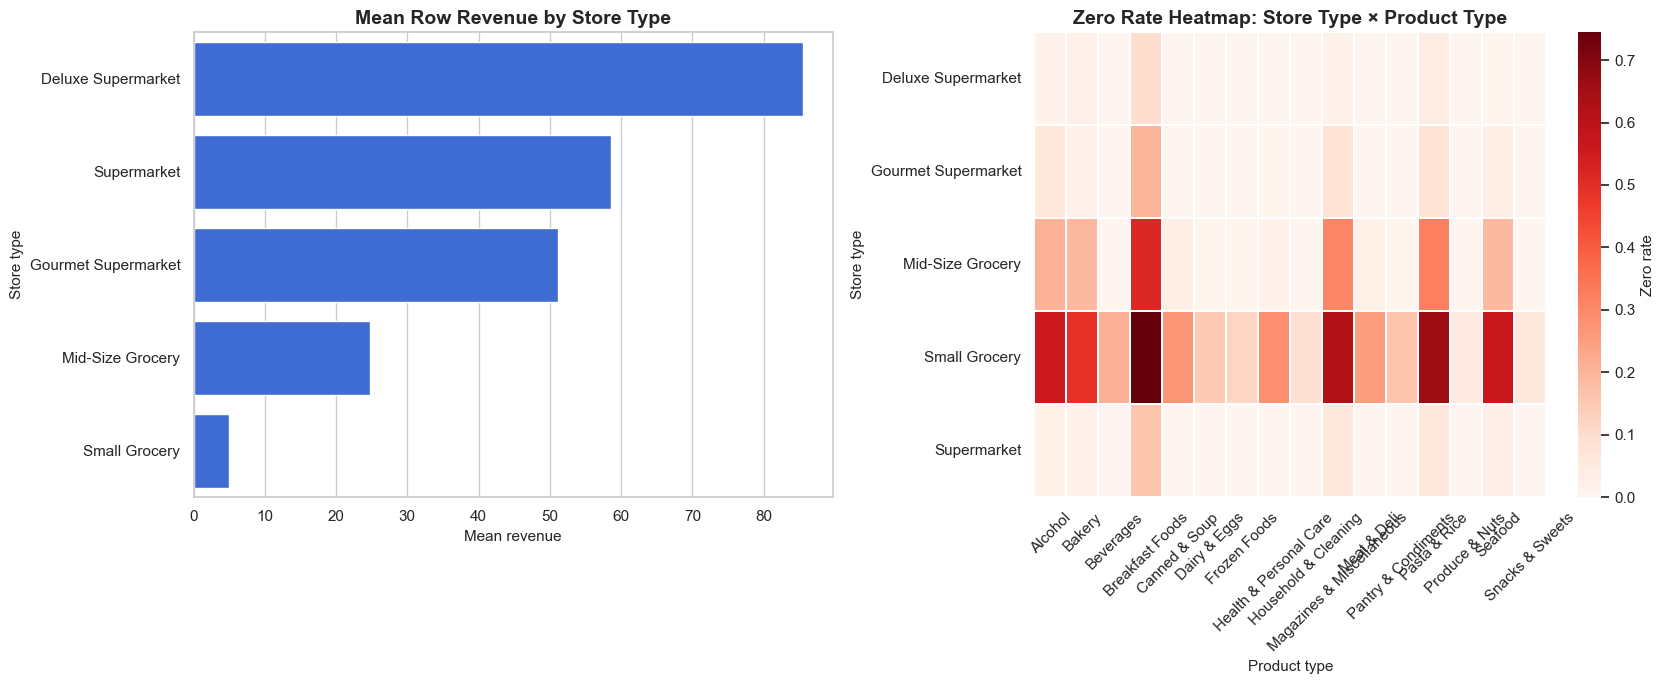

In [19]:
store_type_profile = (
    eda_df.groupby("store_type")
    .agg(
        stores=("store_id", "nunique"),
        rows=("revenue", "size"),
        total_revenue=("revenue", "sum"),
        mean_revenue=("revenue", "mean"),
        zero_rate=("revenue", lambda s: (s == 0).mean()),
        avg_sqft=("total_sqft", "mean"),
        avg_grocery_ratio=("grocery_sqft_ratio", "mean"),
    )
    .reset_index()
    .sort_values("mean_revenue", ascending=False)
)
display(store_type_profile.round({
    "total_revenue": 2, "mean_revenue": 2, "zero_rate": 3,
    "avg_sqft": 0, "avg_grocery_ratio": 3,
}))

store_type_product = (
    eda_df.groupby(["store_type", "product_type"])
    .agg(
        mean_revenue=("revenue", "mean"),
        zero_rate=("revenue", lambda s: (s == 0).mean()),
        total_revenue=("revenue", "sum"),
    )
    .reset_index()
)

zero_by_store_type = store_type_product.sort_values("zero_rate", ascending=False).head(25)
display(zero_by_store_type.round({"mean_revenue": 2, "zero_rate": 3, "total_revenue": 2}))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.barplot(data=store_type_profile, y="store_type", x="mean_revenue", color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Mean Row Revenue by Store Type")
axes[0].set_xlabel("Mean revenue")
axes[0].set_ylabel("Store type")

store_type_zero_heat = store_type_product.pivot(index="store_type", columns="product_type", values="zero_rate")
sns.heatmap(store_type_zero_heat, cmap="Reds", linewidths=0.3, cbar_kws={"label": "Zero rate"}, ax=axes[1])
axes[1].set_title("Zero Rate Heatmap: Store Type × Product Type")
axes[1].set_xlabel("Product type")
axes[1].set_ylabel("Store type")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Insight**

`Small Grocery` không chỉ có doanh thu thấp, mà còn có zero-rate cực cao ở nhiều product type. Ví dụ `Breakfast Foods`, `Pasta & Rice`, `Magazines & Miscellaneous`, `Seafood`, `Alcohol` thường xuyên bằng 0 trong Small Grocery.

Đây là pattern cấu trúc, không phải noise. Model cần biết `store_type`, `store_id`, `product_type` và lịch sử zero/rolling để không overpredict các nhóm sparse tại cửa hàng nhỏ.


### 11.3. Store × Product Hidden Structure

Câu hỏi: doanh thu có bị chi phối bởi một vài cặp store-product không? Nếu có, baseline `store_id × product_type` là bắt buộc.


,store_id,store_city,store_type,product_type,revenue,mean_revenue,zero_rate,revenue_share,cum_share
93,13,Salem,Deluxe Supermarket,Produce & Nuts,"25,207.1200",210.0600,0.0000,0.0210,0.0210
157,17,Tacoma,Deluxe Supermarket,Produce & Nuts,"22,767.0000",189.7200,0.0000,0.0190,0.0410
95,13,Salem,Deluxe Supermarket,Snacks & Sweets,"21,788.3700",181.5700,0.0000,0.0180,0.0590
159,17,Tacoma,Deluxe Supermarket,Snacks & Sweets,"20,299.2600",169.1600,0.0000,0.0170,0.0760
88,13,Salem,Deluxe Supermarket,Household & Cleaning,"19,960.9300",166.3400,0.0000,0.0170,0.0930
152,17,Tacoma,Deluxe Supermarket,Household & Cleaning,"18,326.7900",152.7200,0.0000,0.0160,0.1090
86,13,Salem,Deluxe Supermarket,Frozen Foods,"16,942.2900",141.1900,0.0000,0.0140,0.1230
77,11,Portland,Supermarket,Produce & Nuts,"16,810.6300",140.0900,0.0000,0.0140,0.1380
125,15,Seattle,Supermarket,Produce & Nuts,"16,265.0700",135.5400,0.0000,0.0140,0.1510
61,7,Los Angeles,Supermarket,Produce & Nuts,"15,890.6100",132.4200,0.0000,0.0130,0.1650


Top 10 store-product combos share: 0.165
Top 20 store-product combos share: 0.292


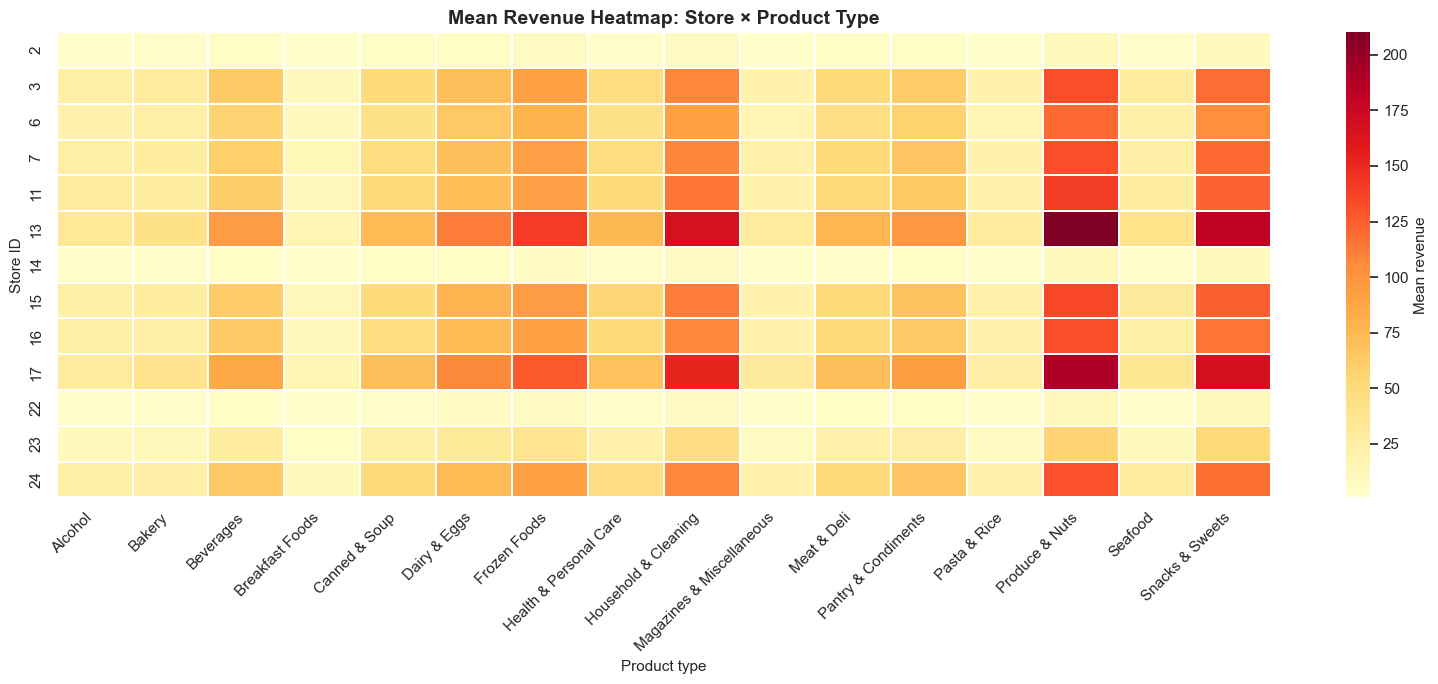

In [20]:
store_product_profile = (
    eda_df.groupby(["store_id", "store_city", "store_type", "product_type"])
    .agg(
        revenue=("revenue", "sum"),
        mean_revenue=("revenue", "mean"),
        zero_rate=("revenue", lambda s: (s == 0).mean()),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)
store_product_profile["revenue_share"] = store_product_profile["revenue"] / store_product_profile["revenue"].sum()
store_product_profile["cum_share"] = store_product_profile["revenue_share"].cumsum()

display(store_product_profile.head(20).round({
    "revenue": 2, "mean_revenue": 2, "zero_rate": 3,
    "revenue_share": 3, "cum_share": 3,
}))
print("Top 10 store-product combos share:", round(store_product_profile.head(10)["revenue_share"].sum(), 3))
print("Top 20 store-product combos share:", round(store_product_profile.head(20)["revenue_share"].sum(), 3))

store_product_heat = eda_df.groupby(["store_id", "product_type"])["revenue"].mean().unstack("product_type")
plt.figure(figsize=(16, 7))
sns.heatmap(store_product_heat, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Mean revenue"})
plt.title("Mean Revenue Heatmap: Store × Product Type")
plt.xlabel("Product type")
plt.ylabel("Store ID")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Insight**

Top 20 cặp store-product chiếm gần 30% tổng doanh thu, trong đó các cặp của `Deluxe Supermarket` với `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`, `Frozen Foods` nổi bật. Đây là lý do baseline `store_product_mean` đã rất mạnh trong modeling.

Nhưng concentration không quá cực đoan như M5: top 10 chỉ khoảng 16-17%. Vì vậy model vẫn cần học pattern sản phẩm/store type/mùa vụ, không thể chỉ ghi nhớ vài cặp lớn.


### 11.4. Product Seasonality: Q4 Lift Có Thật Nhưng Không Đều

Giả thuyết H1:

> Doanh thu tăng ở cuối năm, nhưng mức tăng khác nhau theo `product_type`.


,product_type,peak_month,peak_index,trough_month,trough_index,amplitude_pct
0,Alcohol,12,1.4900,8,0.9090,63.9000
3,Breakfast Foods,12,1.5190,7,0.9500,59.9000
2,Beverages,12,1.5200,2,0.9570,58.7000
1,Bakery,11,1.5540,10,0.9890,57.1000
4,Canned & Soup,11,1.5090,7,0.9850,53.2000
10,Meat & Deli,12,1.4120,10,0.9250,52.7000
12,Pasta & Rice,12,1.4280,9,0.9530,49.8000
11,Pantry & Condiments,12,1.4480,5,0.9780,48.0000
9,Magazines & Miscellaneous,3,1.2560,1,0.8560,46.7000
14,Seafood,12,1.3920,5,0.9710,43.3000


is_q4,0,1,q4_lift_pct
product_type,,,
Canned & Soup,1.0590,1.3460,27.1220
Beverages,1.0530,1.3050,23.8820
Pasta & Rice,1.0640,1.2930,21.5730
Bakery,1.0860,1.3150,21.0880
Household & Cleaning,1.0280,1.2370,20.3260
Health & Personal Care,1.0540,1.2670,20.1540
Pantry & Condiments,1.0480,1.2550,19.8080
Breakfast Foods,1.1440,1.3570,18.6010
Seafood,1.0960,1.2990,18.5500


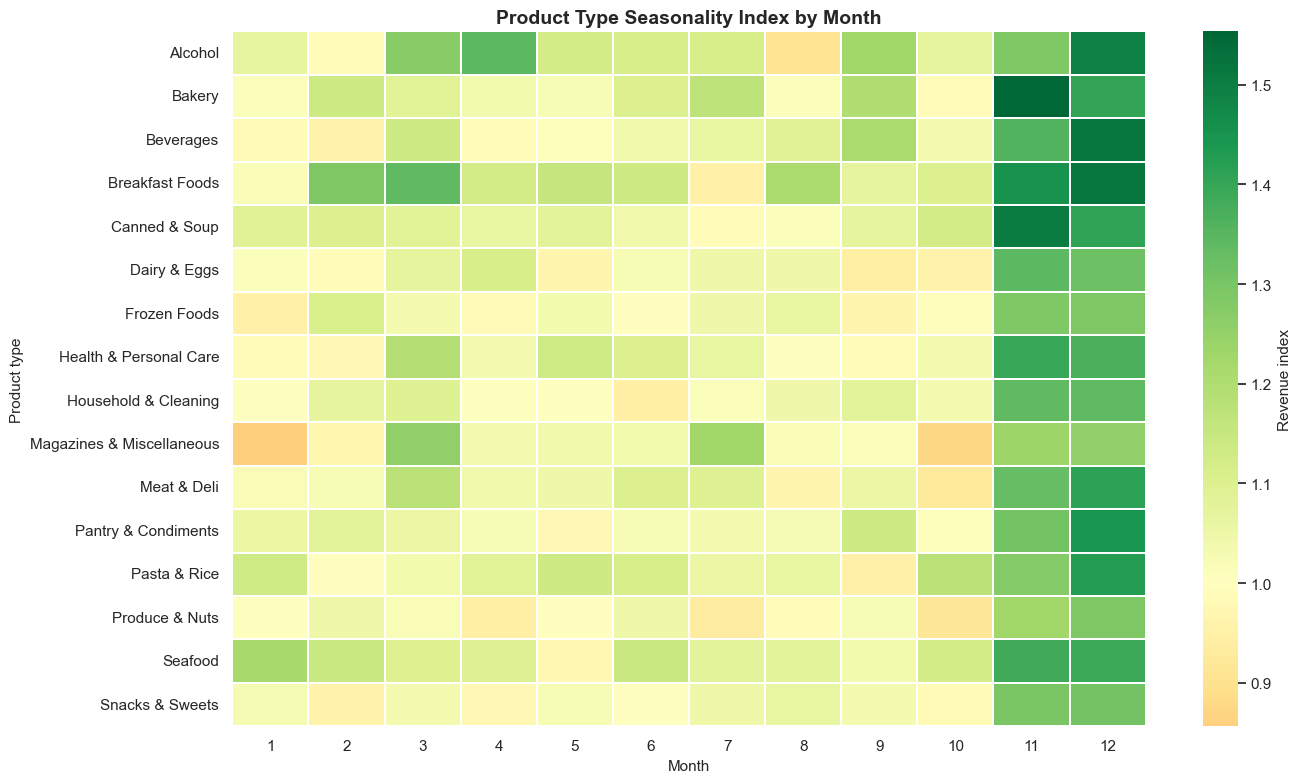

In [21]:
monthly_product_index = (
    eda_df.groupby(["product_type", "month"])
    .agg(mean_index=("revenue_index", "mean"), mean_revenue=("revenue", "mean"), total_revenue=("revenue", "sum"))
    .reset_index()
)

peak_month = monthly_product_index.loc[
    monthly_product_index.groupby("product_type")["mean_index"].idxmax(),
    ["product_type", "month", "mean_index"],
].rename(columns={"month": "peak_month", "mean_index": "peak_index"})

trough_month = monthly_product_index.loc[
    monthly_product_index.groupby("product_type")["mean_index"].idxmin(),
    ["product_type", "month", "mean_index"],
].rename(columns={"month": "trough_month", "mean_index": "trough_index"})

seasonality_product = peak_month.merge(trough_month, on="product_type")
seasonality_product["amplitude_pct"] = (seasonality_product["peak_index"] / seasonality_product["trough_index"] - 1) * 100
seasonality_product = seasonality_product.sort_values("amplitude_pct", ascending=False)
display(seasonality_product.round({"peak_index": 3, "trough_index": 3, "amplitude_pct": 1}))

q4_effect_product = eda_df.groupby(["product_type", "is_q4"])["revenue_index"].mean().unstack()
q4_effect_product["q4_lift_pct"] = (q4_effect_product[1] / q4_effect_product[0] - 1) * 100
q4_effect_product = q4_effect_product.sort_values("q4_lift_pct", ascending=False)
display(q4_effect_product.round(3))

month_index_pivot = monthly_product_index.pivot(index="product_type", columns="month", values="mean_index")
plt.figure(figsize=(14, 8))
sns.heatmap(month_index_pivot, cmap="RdYlGn", center=1.0, linewidths=0.3, cbar_kws={"label": "Revenue index"})
plt.title("Product Type Seasonality Index by Month")
plt.xlabel("Month")
plt.ylabel("Product type")
plt.tight_layout()
plt.show()


**Kết luận H1**

Chấp nhận giả thuyết: Q4 lift xuất hiện ở tất cả product type, nhưng mức độ khác nhau. `Canned & Soup`, `Beverages`, `Pasta & Rice`, `Bakery`, `Household & Cleaning`, `Health & Personal Care` có Q4 lift mạnh. `Magazines & Miscellaneous` tăng ít nhất.

Điều này giải thích vì sao seasonal baseline `store_product_mean × product_month_factor` cạnh tranh tốt với Ridge. Model cần month/quarter/cyclic features và tương tác ngầm với `product_type`.


### 11.5. Weekend Effect: Yếu Và Không Đồng Nhất

Giả thuyết H2:

> Weekend làm doanh thu tăng.

Ta kiểm tra bằng revenue index và approximate 95% CI theo product type.


,product_type,n_positive_groups,n_other_groups,mean_positive,mean_other,diff_index,ci_low,ci_high,lift_pct
3,Breakfast Foods,188,461,1.3850,1.1320,0.2530,0.0410,0.4660,22.4000
6,Frozen Foods,188,461,1.1230,1.0470,0.0770,-0.0030,0.1560,7.3000
12,Pasta & Rice,188,461,1.1970,1.1480,0.0490,-0.0910,0.1890,4.3000
8,Household & Cleaning,188,461,1.0990,1.0730,0.0260,-0.0410,0.0920,2.4000
4,Canned & Soup,188,461,1.1320,1.1100,0.0220,-0.0750,0.1190,2.0000
9,Magazines & Miscellaneous,188,461,1.0880,1.0820,0.0050,-0.1310,0.1420,0.5000
13,Produce & Nuts,188,461,1.0250,1.0450,-0.0210,-0.0750,0.0340,-2.0000
0,Alcohol,188,461,1.1500,1.1750,-0.0260,-0.1580,0.1070,-2.2000
2,Beverages,188,461,1.0900,1.1180,-0.0280,-0.1230,0.0670,-2.5000
1,Bakery,188,461,1.1170,1.1460,-0.0300,-0.1550,0.0950,-2.6000


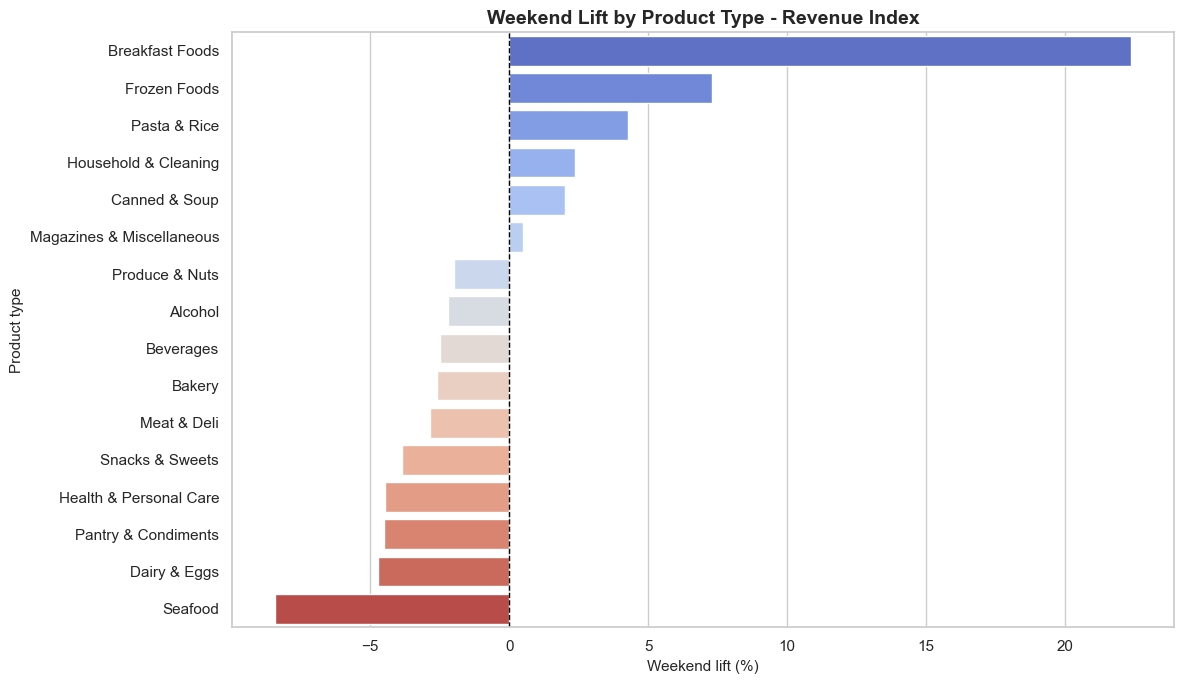

In [22]:
weekend_ci_product = mean_diff_ci_by_product(eda_df, "is_weekend", positive_value=1).sort_values("lift_pct", ascending=False)
display(weekend_ci_product.round({
    "mean_positive": 3, "mean_other": 3, "diff_index": 3,
    "ci_low": 3, "ci_high": 3, "lift_pct": 1,
}))

plt.figure(figsize=(12, 7))
sns.barplot(data=weekend_ci_product, y="product_type", x="lift_pct", palette="coolwarm")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Weekend Lift by Product Type - Revenue Index")
plt.xlabel("Weekend lift (%)")
plt.ylabel("Product type")
plt.tight_layout()
plt.show()


**Kết luận H2**

Không thể nói weekend luôn tăng doanh thu trong dataset Maven. `Breakfast Foods` có weekend lift cao nhất, nhưng CI khá rộng do nhóm này sparse. Nhiều product type có lift gần 0 hoặc âm nhẹ, và CI thường cắt 0.

Vì vậy `is_weekend/day_of_week` vẫn nên giữ như feature phụ, nhưng không phải signal chính. Signal chính vẫn là store-product baseline, month seasonality và history.


### 11.6. Weather/Rain Effect: Tín Hiệu Trực Tiếp Yếu

Giả thuyết H3:

> Mưa/thời tiết có ảnh hưởng rõ tới doanh thu product type.


,product_type,n_positive_groups,n_other_groups,mean_positive,mean_other,diff_index,ci_low,ci_high,lift_pct
7,Health & Personal Care,379,489,1.1290,1.1010,0.0270,-0.0610,0.1160,2.5000
3,Breakfast Foods,379,489,1.1940,1.1690,0.0240,-0.1390,0.1880,2.1000
14,Seafood,379,489,1.1550,1.1400,0.0150,-0.1140,0.1450,1.4000
10,Meat & Deli,379,489,1.1150,1.1000,0.0150,-0.0690,0.0980,1.3000
15,Snacks & Sweets,379,489,1.0750,1.0620,0.0130,-0.0450,0.0700,1.2000
6,Frozen Foods,379,489,1.0680,1.0600,0.0080,-0.0580,0.0740,0.8000
11,Pantry & Condiments,379,489,1.1140,1.1060,0.0080,-0.0660,0.0830,0.7000
13,Produce & Nuts,379,489,1.0470,1.0410,0.0070,-0.0480,0.0610,0.6000
1,Bakery,379,489,1.1550,1.1550,-0.0010,-0.1190,0.1180,-0.0000
8,Household & Cleaning,379,489,1.0760,1.0830,-0.0060,-0.0680,0.0550,-0.6000


,temperature_mean_c,precipitation_mm,snowfall_cm,wind_speed_max_kmh,shortwave_radiation_mj_m2
product_type,,,,,
Alcohol,-0.0260,-0.0170,0.0060,0.0180,-0.0160
Bakery,-0.0340,0.0190,0.0220,0.0070,-0.0440
Beverages,-0.0680,0.0150,0.0200,0.0430,-0.0520
Breakfast Foods,-0.0570,0.0560,0.0340,0.0260,-0.0380
Canned & Soup,-0.0860,-0.0090,-0.0020,-0.0000,-0.0900
Dairy & Eggs,-0.0760,0.0000,0.0090,-0.0150,-0.0570
Frozen Foods,-0.0540,0.0370,0.0320,0.0660,-0.0580
Health & Personal Care,-0.0780,-0.0140,0.0210,-0.0060,-0.0490
Household & Cleaning,-0.0800,0.0180,0.0470,0.0290,-0.1140


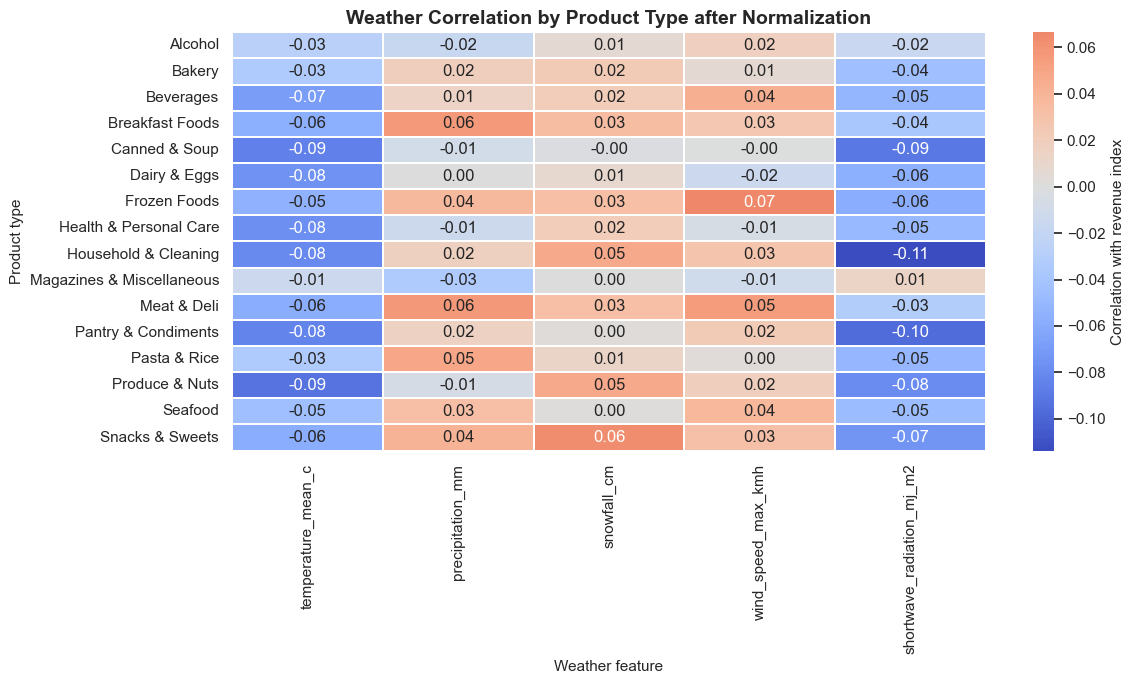

In [23]:
rain_ci_product = mean_diff_ci_by_product(eda_df, "is_rainy_day", positive_value=1).sort_values("lift_pct", ascending=False)
display(rain_ci_product.round({
    "mean_positive": 3, "mean_other": 3, "diff_index": 3,
    "ci_low": 3, "ci_high": 3, "lift_pct": 1,
}))

weather_signal_cols = ["temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh", "shortwave_radiation_mj_m2"]
weather_corr_rows = []
for product_type, sub in eda_df.groupby("product_type"):
    row = {"product_type": product_type}
    for col in weather_signal_cols:
        row[col] = sub["revenue_index"].corr(sub[col])
    weather_corr_rows.append(row)

weather_corr_by_product = pd.DataFrame(weather_corr_rows).set_index("product_type")
display(weather_corr_by_product.round(3))

plt.figure(figsize=(12, 7))
sns.heatmap(weather_corr_by_product, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.3, cbar_kws={"label": "Correlation with revenue index"})
plt.title("Weather Correlation by Product Type after Normalization")
plt.xlabel("Weather feature")
plt.ylabel("Product type")
plt.tight_layout()
plt.show()


**Kết luận H3**

Không có bằng chứng mạnh rằng weather là driver chính của doanh thu trong dataset này. Rain lift đa số nhỏ và CI thường cắt 0; correlation weather sau khi normalize cũng yếu.

Điều này ủng hộ quyết định model chính không phụ thuộc weather. Weather có thể giữ cho EDA/extension, nhưng không nên kỳ vọng cải thiện lớn nếu không có signal mạnh hơn hoặc weather forecast tốt hơn.


### 11.7. Trend/Drift: Test Period Cao Hơn Train Ở Hầu Hết Product Type

Câu hỏi: revenue có drift theo thời gian không? Nếu có, mean baseline sẽ underpredict giai đoạn test.


year,1997,1998,1998_vs_1997_pct
product_type,,,
Breakfast Foods,8.9000,10.1600,14.2100
Pantry & Condiments,49.9700,55.3900,10.8400
Alcohol,17.9900,19.8200,10.1900
Bakery,21.1000,23.2300,10.0900
Meat & Deli,39.5200,43.5000,10.0700
Household & Cleaning,83.7500,91.9800,9.8200
Health & Personal Care,37.8200,41.4400,9.5700
Frozen Foods,70.7800,77.5100,9.5100
Beverages,48.0600,52.4500,9.1300


split,test,train,test_vs_train_pct
product_type,,,
Bakery,24.9800,21.2200,17.7400
Meat & Deli,45.8300,40.0600,14.4000
Household & Cleaning,96.8000,84.8900,14.0300
Pantry & Condiments,57.7600,50.9800,13.3100
Alcohol,20.6900,18.3100,13.0100
Beverages,54.9300,48.6900,12.8200
Magazines & Miscellaneous,17.3800,15.4800,12.2900
Frozen Foods,80.4800,72.0300,11.7200
Health & Personal Care,42.8900,38.5400,11.2800


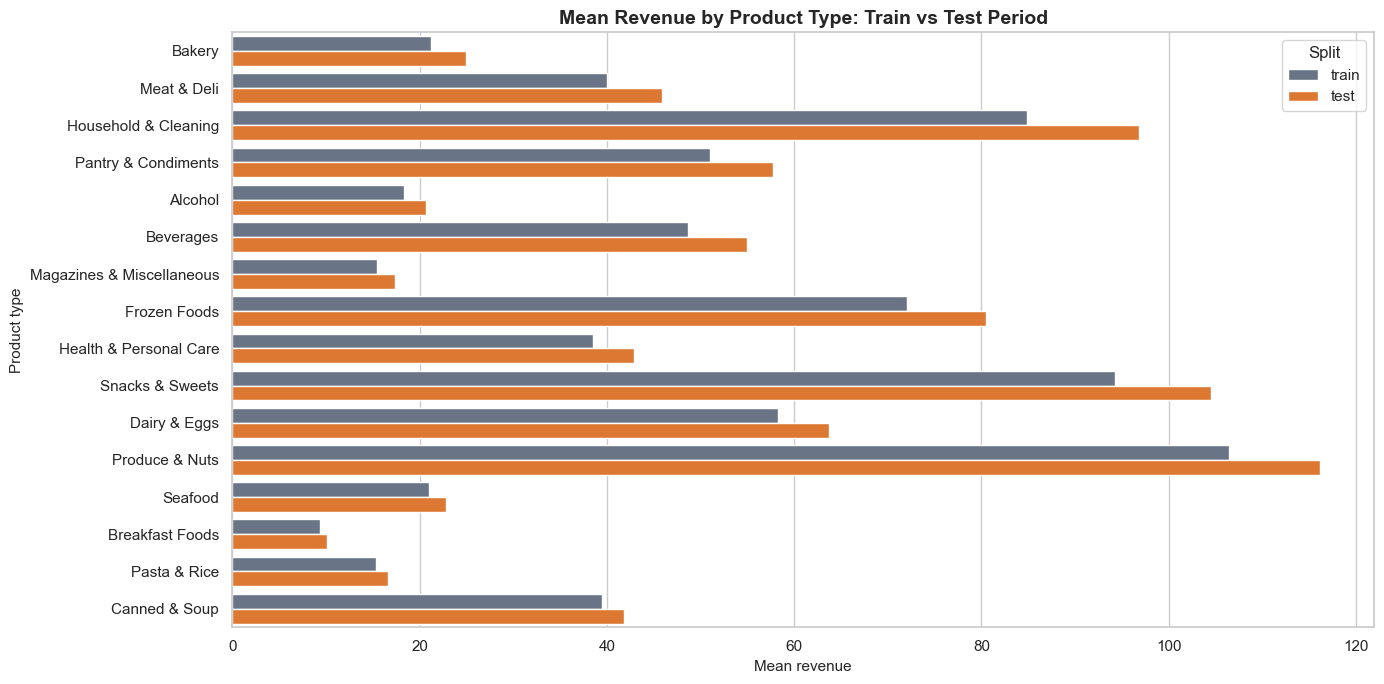

In [24]:
yearly_product_mean = eda_df.groupby(["product_type", "year"])["revenue"].mean().unstack()
yearly_product_mean["1998_vs_1997_pct"] = (yearly_product_mean[1998] / yearly_product_mean[1997] - 1) * 100
yearly_product_mean = yearly_product_mean.sort_values("1998_vs_1997_pct", ascending=False)
display(yearly_product_mean.round(2))

split_product_mean = eda_df.groupby(["product_type", "split"])["revenue"].mean().unstack()
split_product_mean["test_vs_train_pct"] = (split_product_mean["test"] / split_product_mean["train"] - 1) * 100
split_product_mean = split_product_mean.sort_values("test_vs_train_pct", ascending=False)
display(split_product_mean.round(2))

split_plot = split_product_mean.reset_index().melt(
    id_vars="product_type",
    value_vars=["train", "test"],
    var_name="split",
    value_name="mean_revenue",
)
plt.figure(figsize=(14, 7))
sns.barplot(data=split_plot, y="product_type", x="mean_revenue", hue="split", palette=[COLOR_GRAY, COLOR_ACCENT])
plt.title("Mean Revenue by Product Type: Train vs Test Period")
plt.xlabel("Mean revenue")
plt.ylabel("Product type")
plt.legend(title="Split")
plt.tight_layout()
plt.show()


**Insight drift**

Test period cao hơn train ở hầu hết product type, đặc biệt `Bakery`, `Meat & Deli`, `Household & Cleaning`, `Pantry & Condiments`, `Alcohol`, `Beverages`. Điều này giải thích bias âm của baseline `store_product_mean`: dùng trung bình quá khứ dễ underpredict khi level doanh thu tăng.

Model cần history gần nhất, trend/calendar và seasonal factor để bám mức doanh thu mới.


### 11.8. Lag Strength: History Có Signal Nhưng Không Mạnh Như M5

Giả thuyết H4:

> Doanh thu quá khứ của cùng `store_id × product_type` giúp dự báo doanh thu tương lai.

Lưu ý: `lag_1_obs` ở Maven là lần quan sát trước đó, không phải hôm qua, vì mỗi store chỉ có 5 observed days/tháng.


,product_type,corr_lag_1_obs,corr_lag_2_obs,corr_lag_3_obs,corr_lag_6_obs,corr_lag_12_obs
15,Snacks & Sweets,0.7420,0.7170,0.6940,0.6700,0.6810
13,Produce & Nuts,0.7250,0.7140,0.6710,0.6440,0.6690
8,Household & Cleaning,0.7030,0.6760,0.6450,0.6190,0.6480
6,Frozen Foods,0.6900,0.6560,0.6000,0.5710,0.6050
11,Pantry & Condiments,0.6560,0.6450,0.6220,0.5970,0.5940
10,Meat & Deli,0.6210,0.5920,0.5660,0.5330,0.5430
2,Beverages,0.6190,0.6300,0.5940,0.5560,0.5750
5,Dairy & Eggs,0.6170,0.6030,0.5650,0.5600,0.5400
7,Health & Personal Care,0.6010,0.5610,0.5400,0.5090,0.5730
4,Canned & Soup,0.5990,0.5570,0.5360,0.5170,0.5550


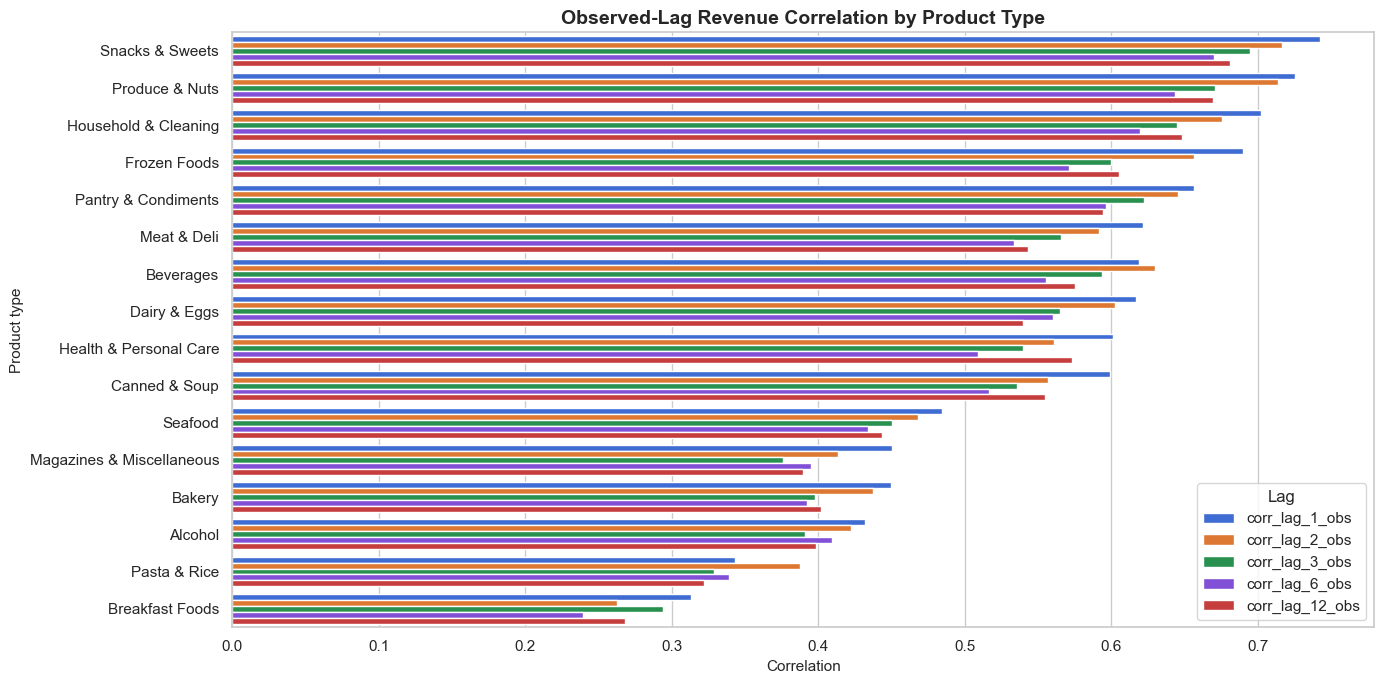

In [25]:
lag_check = eda_df.sort_values(["store_id", "product_type", "transaction_date"]).copy()
lag_group = lag_check.groupby(["store_id", "product_type"], sort=False)
for lag in [1, 2, 3, 6, 12]:
    lag_check[f"lag_{lag}_obs"] = lag_group["revenue"].shift(lag)

lag_corr_rows = []
for product_type, sub in lag_check.groupby("product_type"):
    row = {"product_type": product_type}
    for lag in [1, 2, 3, 6, 12]:
        tmp = sub[["revenue", f"lag_{lag}_obs"]].dropna()
        row[f"corr_lag_{lag}_obs"] = tmp["revenue"].corr(tmp[f"lag_{lag}_obs"])
    lag_corr_rows.append(row)

lag_corr_product = pd.DataFrame(lag_corr_rows).sort_values("corr_lag_1_obs", ascending=False)
display(lag_corr_product.round(3))

lag_corr_plot = lag_corr_product.melt(id_vars="product_type", var_name="lag", value_name="correlation")
plt.figure(figsize=(14, 7))
sns.barplot(data=lag_corr_plot, y="product_type", x="correlation", hue="lag", palette=PALETTE_CONTRAST)
plt.title("Observed-Lag Revenue Correlation by Product Type")
plt.xlabel("Correlation")
plt.ylabel("Product type")
plt.legend(title="Lag")
plt.tight_layout()
plt.show()


**Kết luận H4**

History có signal rõ, nhất là với nhóm volume cao như `Snacks & Sweets`, `Produce & Nuts`, `Household & Cleaning`, `Frozen Foods`. Nhưng các nhóm sparse như `Breakfast Foods`, `Pasta & Rice`, `Alcohol`, `Bakery`, `Magazines & Miscellaneous` có lag correlation yếu hơn nhiều.

Điều này giải thích vì sao final blend tốt hơn chỉ dùng lag đơn giản: model cần kết hợp history với store-product baseline và seasonality.


### 11.9. Tổng Hợp Insight Trước Modeling

Bảng này nối trực tiếp insight với quyết định feature/model, để modeling có cơ sở thay vì chỉ thử thuật toán.


In [26]:
deep_insight_summary = pd.DataFrame([
    {
        "finding": "Product scale rất lệch",
        "evidence": "Produce & Nuts, Snacks & Sweets, Household & Cleaning dẫn đầu; Breakfast Foods chỉ ~1.3% revenue",
        "model_implication": "Phải đánh giá lỗi theo product_type, không chỉ metric tổng.",
    },
    {
        "finding": "Small Grocery là segment khác biệt",
        "evidence": "Small Grocery có zero-rate ~33%, nhiều product sparse như Breakfast Foods/Pasta & Rice",
        "model_implication": "Cần store_type/store_id và zero-rate history để tránh overpredict.",
    },
    {
        "finding": "Store × product baseline mạnh",
        "evidence": "Top 20 store-product combos chiếm gần 30% revenue",
        "model_implication": "store_product_mean là baseline mạnh và nên đưa store_id/product_type vào model.",
    },
    {
        "finding": "Q4 seasonality rõ nhưng không đều",
        "evidence": "Canned & Soup/Beverages/Pasta & Rice Q4 lift mạnh; Magazines tăng yếu",
        "model_implication": "Cần month/quarter/cyclic features và product-month seasonal factor.",
    },
    {
        "finding": "Weekend effect yếu",
        "evidence": "Nhiều product_type có CI cắt 0; Breakfast Foods là nhóm weekend lift rõ nhất",
        "model_implication": "day_of_week/is_weekend là feature phụ, không phải signal chính.",
    },
    {
        "finding": "Weather trực tiếp yếu",
        "evidence": "Rain lift và weather correlations đa số nhỏ sau normalize",
        "model_implication": "No-weather model chính là hợp lý; weather chỉ là extension.",
    },
    {
        "finding": "Có drift tăng trong test period",
        "evidence": "Test mean cao hơn train ở hầu hết product_type",
        "model_implication": "Mean baseline dễ underpredict; cần trend/history/seasonality gần thời điểm dự báo.",
    },
    {
        "finding": "History signal không đồng đều",
        "evidence": "Lag correlation mạnh ở nhóm volume cao, yếu ở nhóm sparse",
        "model_implication": "Blend seasonal baseline + Ridge history hợp lý hơn naive lag đơn giản.",
    },
])

display(deep_insight_summary)


,finding,evidence,model_implication
0,Product scale rất lệch,"Produce & Nuts, Snacks & Sweets, Household & C...","Phải đánh giá lỗi theo product_type, không chỉ..."
1,Small Grocery là segment khác biệt,"Small Grocery có zero-rate ~33%, nhiều product...",Cần store_type/store_id và zero-rate history đ...
2,Store × product baseline mạnh,Top 20 store-product combos chiếm gần 30% revenue,store_product_mean là baseline mạnh và nên đưa...
3,Q4 seasonality rõ nhưng không đều,Canned & Soup/Beverages/Pasta & Rice Q4 lift m...,Cần month/quarter/cyclic features và product-m...
4,Weekend effect yếu,Nhiều product_type có CI cắt 0; Breakfast Food...,"day_of_week/is_weekend là feature phụ, không p..."
5,Weather trực tiếp yếu,Rain lift và weather correlations đa số nhỏ sa...,No-weather model chính là hợp lý; weather chỉ ...
6,Có drift tăng trong test period,Test mean cao hơn train ở hầu hết product_type,Mean baseline dễ underpredict; cần trend/histo...
7,History signal không đồng đều,"Lag correlation mạnh ở nhóm volume cao, yếu ở ...",Blend seasonal baseline + Ridge history hợp lý...


## 12. Feature Engineering Không Leakage


In [27]:
def add_calendar_features(data):
    out = data.copy()
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week_num"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week_num"] / 7)
    out["day_sin"] = np.sin(2 * np.pi * out["day"] / 31)
    out["day_cos"] = np.cos(2 * np.pi * out["day"] / 31)
    return out


def add_history_features(data):
    out = data.sort_values(["store_id", "product_type", "transaction_date"]).copy()
    group = out.groupby(["store_id", "product_type"], sort=False)

    for lag in [1, 2, 3]:
        out[f"revenue_lag_{lag}_obs"] = group["revenue"].shift(lag)

    shifted_revenue = group["revenue"].shift(1)
    out["revenue_roll_mean_3_obs"] = (
        shifted_revenue.groupby([out["store_id"], out["product_type"]])
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    out["revenue_roll_mean_6_obs"] = (
        shifted_revenue.groupby([out["store_id"], out["product_type"]])
        .rolling(6, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    out["revenue_roll_std_6_obs"] = (
        shifted_revenue.groupby([out["store_id"], out["product_type"]])
        .rolling(6, min_periods=2)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )

    shifted_zero = group["had_observed_transaction_row"].shift(1).rsub(1)
    out["zero_rate_roll_6_obs"] = (
        shifted_zero.groupby([out["store_id"], out["product_type"]])
        .rolling(6, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )

    out["sp_expanding_mean"] = group["revenue"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    out["days_since_prev_obs"] = group["transaction_date"].diff().dt.days
    return out


df_model = panel.pipe(add_calendar_features).pipe(add_history_features)

history_cols = [
    "revenue_lag_1_obs", "revenue_lag_2_obs", "revenue_lag_3_obs",
    "revenue_roll_mean_3_obs", "revenue_roll_mean_6_obs", "revenue_roll_std_6_obs",
    "zero_rate_roll_6_obs", "sp_expanding_mean", "days_since_prev_obs",
]

display(df_model[key_cols + ["revenue"] + history_cols].head(12))

print("Modeling rows:", df_model.shape[0])
print("Target zero rate:", (df_model["revenue"] == 0).mean().round(4))
print("History feature missing counts:")
display(df_model[history_cols].isna().sum().to_frame("missing_count"))


,transaction_date,store_id,product_type,revenue,revenue_lag_1_obs,revenue_lag_2_obs,revenue_lag_3_obs,revenue_roll_mean_3_obs,revenue_roll_mean_6_obs,revenue_roll_std_6_obs,zero_rate_roll_6_obs,sp_expanding_mean,days_since_prev_obs
0,1997-01-05,2,Alcohol,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1997-01-08,2,Alcohol,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN,1.0000,0.0000,3.0000
2,1997-01-10,2,Alcohol,7.5800,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,1.0000,0.0000,2.0000
3,1997-01-28,2,Alcohol,0.0000,7.5800,0.0000,0.0000,2.5267,2.5267,4.3763,0.6667,2.5267,18.0000
4,1997-01-29,2,Alcohol,0.0000,0.0000,7.5800,0.0000,2.5267,1.8950,3.7900,0.7500,1.8950,1.0000
5,1997-02-02,2,Alcohol,0.0000,0.0000,0.0000,7.5800,2.5267,1.5160,3.3899,0.8000,1.5160,4.0000
6,1997-02-04,2,Alcohol,0.0000,0.0000,0.0000,0.0000,0.0000,1.2633,3.0945,0.8333,1.2633,2.0000
7,1997-02-07,2,Alcohol,0.0000,0.0000,0.0000,0.0000,0.0000,1.2633,3.0945,0.8333,1.0829,3.0000
8,1997-02-10,2,Alcohol,0.0000,0.0000,0.0000,0.0000,0.0000,1.2633,3.0945,0.8333,0.9475,3.0000
9,1997-02-23,2,Alcohol,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.8422,13.0000


Modeling rows: 24960
Target zero rate: 0.0995
History feature missing counts:


,missing_count
revenue_lag_1_obs,208
revenue_lag_2_obs,416
revenue_lag_3_obs,624
revenue_roll_mean_3_obs,208
revenue_roll_mean_6_obs,208
revenue_roll_std_6_obs,416
zero_rate_roll_6_obs,208
sp_expanding_mean,208
days_since_prev_obs,208


**Feature engineering logic**

Các feature lịch sử đều dùng `shift(1)` trước khi rolling/expanding. Nghĩa là khi dự báo ngày `t`, model chỉ được nhìn doanh thu của các lần quan sát trước `t`. Đây là điểm cốt lõi để tránh leakage.

Do dataset chỉ có 5 observed days mỗi tháng cho mỗi store, `lag_1_obs` nghĩa là lần quan sát trước đó của cùng `store_id × product_type`, không nhất thiết là ngày hôm qua.


## 13. Train/Test Split Theo Thời Gian


In [28]:
SPLIT_DATE = pd.Timestamp("1998-07-01")
train_df = df_model[df_model["transaction_date"] < SPLIT_DATE].copy()
test_df = df_model[df_model["transaction_date"] >= SPLIT_DATE].copy()

print("Train date range:", train_df["transaction_date"].min().date(), "->", train_df["transaction_date"].max().date())
print("Test date range:", test_df["transaction_date"].min().date(), "->", test_df["transaction_date"].max().date())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train months:", sorted(train_df["transaction_date"].dt.to_period("M").astype(str).unique())[:3], "...", sorted(train_df["transaction_date"].dt.to_period("M").astype(str).unique())[-3:])
print("Test months:", sorted(test_df["transaction_date"].dt.to_period("M").astype(str).unique()))


Train date range: 1997-01-01 -> 1998-06-29
Test date range: 1998-07-01 -> 1998-12-30
Train shape: (18720, 50)
Test shape: (6240, 50)
Train months: ['1997-01', '1997-02', '1997-03'] ... ['1998-04', '1998-05', '1998-06']
Test months: ['1998-07', '1998-08', '1998-09', '1998-10', '1998-11', '1998-12']


**Split strategy**

Không dùng random split vì random split sẽ cho model thấy các tháng/ngày tương lai trong train. Notebook dùng:

- Train: `1997-01-01` đến trước `1998-07-01`
- Test: `1998-07-01` đến `1998-12-30`

Cách này mô phỏng bài toán dự báo tương lai tốt hơn.


## 14. Baseline Models


In [29]:
def fit_mean_baselines(train):
    return {
        "global_mean": train["revenue"].mean(),
        "product_mean": train.groupby("product_type")["revenue"].mean(),
        "store_mean": train.groupby("store_id")["revenue"].mean(),
        "store_product_mean": train.groupby(["store_id", "product_type"])["revenue"].mean(),
    }


def predict_mean_baseline(model, data, kind):
    global_mean = model["global_mean"]
    if kind == "global_mean":
        return np.full(len(data), global_mean)
    if kind == "product_mean":
        return data["product_type"].map(model["product_mean"]).fillna(global_mean).values
    if kind == "store_mean":
        return data["store_id"].map(model["store_mean"]).fillna(global_mean).values
    if kind == "store_product_mean":
        idx = data.set_index(["store_id", "product_type"]).index
        return pd.Series(idx.map(model["store_product_mean"]), index=data.index).fillna(global_mean).values
    raise ValueError(kind)


def predict_lag1_baseline(train, data):
    baseline_model = fit_mean_baselines(train)
    idx = data.set_index(["store_id", "product_type"]).index
    fallback = pd.Series(idx.map(baseline_model["store_product_mean"]), index=data.index).fillna(baseline_model["global_mean"])
    return data["revenue_lag_1_obs"].fillna(fallback).values

baseline_artifacts = fit_mean_baselines(train_df)

baseline_rows = []
for name in ["global_mean", "product_mean", "store_mean", "store_product_mean"]:
    pred = predict_mean_baseline(baseline_artifacts, test_df, name)
    baseline_rows.append({"model": name, **evaluate_regression(test_df["revenue"], pred)})

pred_lag1 = predict_lag1_baseline(train_df, test_df)
baseline_rows.append({"model": "lag1_previous_observed", **evaluate_regression(test_df["revenue"], pred_lag1)})

baseline_results = display_metrics_table(baseline_rows)


,model,MAE,RMSE,WAPE,R2,Bias
3,store_product_mean,16.7500,26.0810,0.3278,0.7614,-5.2000
4,lag1_previous_observed,20.8910,31.3740,0.4089,0.6547,-0.3890
2,store_mean,30.8140,45.2540,0.6031,0.2816,-5.2000
1,product_mean,31.0370,42.8470,0.6074,0.3560,-5.2000
0,global_mean,40.6530,53.6430,0.7957,-0.0095,-5.2000


**Baseline insight**

`store_product_mean` là baseline rất mạnh vì mỗi cặp store-product có mức nền doanh thu riêng. Baseline `lag1_previous_observed` không tốt bằng `store_product_mean`, cho thấy dữ liệu lấy mẫu ngắt quãng và có nhiễu theo từng ngày; copy lần quan sát gần nhất không ổn định bằng mức nền dài hạn.


## 15. Seasonal Baseline: Store-Product Mean × Product-Month Factor


In [30]:
def fit_seasonal_baseline(train):
    global_mean = train["revenue"].mean()
    sp_mean = train.groupby(["store_id", "product_type"])["revenue"].mean()
    product_mean = train.groupby("product_type")["revenue"].mean()
    product_month_mean = train.groupby(["product_type", "month"])["revenue"].mean()
    product_month_factor = (product_month_mean / product_mean.reindex(product_month_mean.index.get_level_values(0)).values).rename("factor")
    return {
        "global_mean": global_mean,
        "sp_mean": sp_mean,
        "product_month_factor": product_month_factor,
    }


def predict_seasonal_baseline(model, data):
    idx_sp = data.set_index(["store_id", "product_type"]).index
    sp_pred = pd.Series(idx_sp.map(model["sp_mean"]), index=data.index).fillna(model["global_mean"]).astype(float)

    idx_pm = data.set_index(["product_type", "month"]).index
    factor = pd.Series(idx_pm.map(model["product_month_factor"]), index=data.index).fillna(1.0).astype(float)
    return np.clip(sp_pred.values * factor.values, 0, None)

seasonal_artifacts = fit_seasonal_baseline(train_df)
pred_seasonal = predict_seasonal_baseline(seasonal_artifacts, test_df)
seasonal_result = pd.DataFrame([{"model": "store_product_mean_x_product_month_factor", **evaluate_regression(test_df["revenue"], pred_seasonal)}])
display(seasonal_result.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}))


,model,MAE,RMSE,WAPE,R2,Bias
0,store_product_mean_x_product_month_factor,16.1120,24.8040,0.3153,0.7842,-4.1470


**Insight seasonal baseline**

Baseline này dùng logic retail rất đơn giản: mỗi `store × product` có mức nền, sau đó điều chỉnh theo seasonality của `product_type × month`. Cách này thường đáng tin với dataset ngắn, vì nó ít tham số hơn model phức tạp nhưng vẫn bắt được mùa vụ cuối năm.


## 16. Ridge Regression Tự Cài Bằng Numpy


In [31]:
# Final model deliberately does not use same-day transaction leakage or weather.
numeric_base_features = [
    "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "store_age_years", "years_since_remodel",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "day_sin", "day_cos",
]

numeric_history_features = [
    "revenue_lag_1_obs", "revenue_lag_2_obs", "revenue_lag_3_obs",
    "revenue_roll_mean_3_obs", "revenue_roll_mean_6_obs", "revenue_roll_std_6_obs",
    "zero_rate_roll_6_obs", "sp_expanding_mean", "days_since_prev_obs",
]

categorical_features = [
    "store_id", "product_type", "store_type", "store_state", "sales_region", "sales_district",
    "month", "quarter", "day_of_week_num", "is_weekend",
]


def make_design_matrices(train, pred, numeric_features, categorical_features):
    train_num = train[numeric_features].copy()
    pred_num = pred[numeric_features].copy()

    medians = train_num.median()
    train_num = train_num.fillna(medians).astype(float)
    pred_num = pred_num.fillna(medians).astype(float)

    means = train_num.mean()
    stds = train_num.std().replace(0, 1)

    train_num_scaled = (train_num - means) / stds
    pred_num_scaled = (pred_num - means) / stds

    train_cat = pd.get_dummies(train[categorical_features].astype(str), dtype=float)
    pred_cat = pd.get_dummies(pred[categorical_features].astype(str), dtype=float)
    pred_cat = pred_cat.reindex(columns=train_cat.columns, fill_value=0.0)

    X_train = pd.concat([train_num_scaled.reset_index(drop=True), train_cat.reset_index(drop=True)], axis=1)
    X_pred = pd.concat([pred_num_scaled.reset_index(drop=True), pred_cat.reset_index(drop=True)], axis=1)

    artifacts = {
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "medians": medians,
        "means": means,
        "stds": stds,
        "dummy_columns": train_cat.columns.tolist(),
        "feature_columns": X_train.columns.tolist(),
    }
    return X_train, X_pred, artifacts


def fit_ridge_numpy(train, numeric_features, categorical_features, alpha=25.0):
    X_train, _, artifacts = make_design_matrices(train, train, numeric_features, categorical_features)
    X = X_train.values.astype(float)
    y = train["revenue"].values.astype(float)

    X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
    penalty = np.eye(X_with_intercept.shape[1])
    penalty[0, 0] = 0  # do not regularize intercept

    beta = np.linalg.pinv(X_with_intercept.T @ X_with_intercept + alpha * penalty) @ X_with_intercept.T @ y
    artifacts["beta"] = beta
    artifacts["alpha"] = alpha
    return artifacts


def predict_ridge_numpy(model, data):
    numeric_features = model["numeric_features"]
    categorical_features = model["categorical_features"]

    num = data[numeric_features].copy().fillna(model["medians"]).astype(float)
    num = (num - model["means"]) / model["stds"]

    cat = pd.get_dummies(data[categorical_features].astype(str), dtype=float)
    cat = cat.reindex(columns=model["dummy_columns"], fill_value=0.0)

    X = pd.concat([num.reset_index(drop=True), cat.reset_index(drop=True)], axis=1)
    X = X.reindex(columns=model["feature_columns"], fill_value=0.0).values.astype(float)
    X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
    return np.clip(X_with_intercept @ model["beta"], 0, None)

model_rows = []

ridge_no_history = fit_ridge_numpy(train_df, numeric_base_features, categorical_features, alpha=25.0)
pred_no_history = predict_ridge_numpy(ridge_no_history, test_df)
model_rows.append({"model": "ridge_no_history", **evaluate_regression(test_df["revenue"], pred_no_history)})

ridge_with_history = fit_ridge_numpy(train_df, numeric_base_features + numeric_history_features, categorical_features, alpha=25.0)
pred_ridge = predict_ridge_numpy(ridge_with_history, test_df)
model_rows.append({"model": "ridge_with_history_no_weather", **evaluate_regression(test_df["revenue"], pred_ridge)})

ridge_results = display_metrics_table(model_rows)
print("Number of features in ridge_with_history:", len(ridge_with_history["feature_columns"]))


,model,MAE,RMSE,WAPE,R2,Bias
1,ridge_with_history_no_weather,16.3250,24.4750,0.3195,0.7899,-1.8010
0,ridge_no_history,20.4740,30.1690,0.4007,0.6807,-1.5150


Number of features in ridge_with_history: 97


**Insight Ridge**

Ridge không phải model phức tạp, nhưng nó giúp gom nhiều loại signal: store, product type, store type, month, day-of-week, store size và history features. Việc thêm history features cải thiện kết quả so với Ridge không có history, xác nhận rằng doanh thu quá khứ của cùng store-product có giá trị dự báo.


## 17. Chọn Final Model Bằng Validation: Blend Seasonal Baseline + Ridge


In [32]:
FIT_END = pd.Timestamp("1998-01-01")
VAL_END = pd.Timestamp("1998-07-01")

fit_df = df_model[df_model["transaction_date"] < FIT_END].copy()
val_df = df_model[(df_model["transaction_date"] >= FIT_END) & (df_model["transaction_date"] < VAL_END)].copy()

seasonal_fit = fit_seasonal_baseline(fit_df)
ridge_fit = fit_ridge_numpy(fit_df, numeric_base_features + numeric_history_features, categorical_features, alpha=25.0)

val_pred_seasonal = predict_seasonal_baseline(seasonal_fit, val_df)
val_pred_ridge = predict_ridge_numpy(ridge_fit, val_df)

weight_rows = []
for w in np.arange(0, 1.0001, 0.05):
    blended = w * val_pred_seasonal + (1 - w) * val_pred_ridge
    weight_rows.append({"seasonal_weight": round(float(w), 2), **evaluate_regression(val_df["revenue"], blended)})

weight_results = pd.DataFrame(weight_rows).sort_values("MAE")
display(weight_results.round({"MAE": 3, "RMSE": 3, "WAPE": 4, "R2": 4, "Bias": 3}).head(10))

best_weight = float(weight_results.iloc[0]["seasonal_weight"])
print("Best seasonal weight selected on validation:", best_weight)

# Refit both components on full train period and evaluate once on test.
seasonal_train = fit_seasonal_baseline(train_df)
ridge_train = fit_ridge_numpy(train_df, numeric_base_features + numeric_history_features, categorical_features, alpha=25.0)

test_pred_seasonal = predict_seasonal_baseline(seasonal_train, test_df)
test_pred_ridge = predict_ridge_numpy(ridge_train, test_df)
test_pred_blend = best_weight * test_pred_seasonal + (1 - best_weight) * test_pred_ridge

final_rows = []
final_rows.append({"model": "best_baseline_store_product", **evaluate_regression(test_df["revenue"], predict_mean_baseline(baseline_artifacts, test_df, "store_product_mean"))})
final_rows.append({"model": "seasonal_baseline", **evaluate_regression(test_df["revenue"], test_pred_seasonal)})
final_rows.append({"model": "ridge_with_history_no_weather", **evaluate_regression(test_df["revenue"], test_pred_ridge)})
final_rows.append({"model": f"final_blend_w{best_weight:.2f}_seasonal", **evaluate_regression(test_df["revenue"], test_pred_blend)})

final_model_results = display_metrics_table(final_rows)


,seasonal_weight,MAE,RMSE,WAPE,R2,Bias
10,0.5000,15.0260,22.4130,0.3190,0.7907,-2.3620
11,0.5500,15.0270,22.4430,0.3191,0.7901,-2.4720
9,0.4500,15.0300,22.3880,0.3191,0.7911,-2.2520
12,0.6000,15.0320,22.4790,0.3192,0.7894,-2.5820
8,0.4000,15.0390,22.3690,0.3193,0.7915,-2.1420
13,0.6500,15.0410,22.5200,0.3193,0.7887,-2.6920
7,0.3500,15.0530,22.3550,0.3196,0.7917,-2.0320
14,0.7000,15.0540,22.5660,0.3196,0.7878,-2.8020
15,0.7500,15.0710,22.6170,0.3200,0.7868,-2.9120
6,0.3000,15.0730,22.3470,0.3200,0.7919,-1.9220


Best seasonal weight selected on validation: 0.5


,model,MAE,RMSE,WAPE,R2,Bias
3,final_blend_w0.50_seasonal,15.9980,24.3730,0.3131,0.7916,-2.9740
1,seasonal_baseline,16.1120,24.8040,0.3153,0.7842,-4.1470
2,ridge_with_history_no_weather,16.3250,24.4750,0.3195,0.7899,-1.8010
0,best_baseline_store_product,16.7500,26.0810,0.3278,0.7614,-5.2000


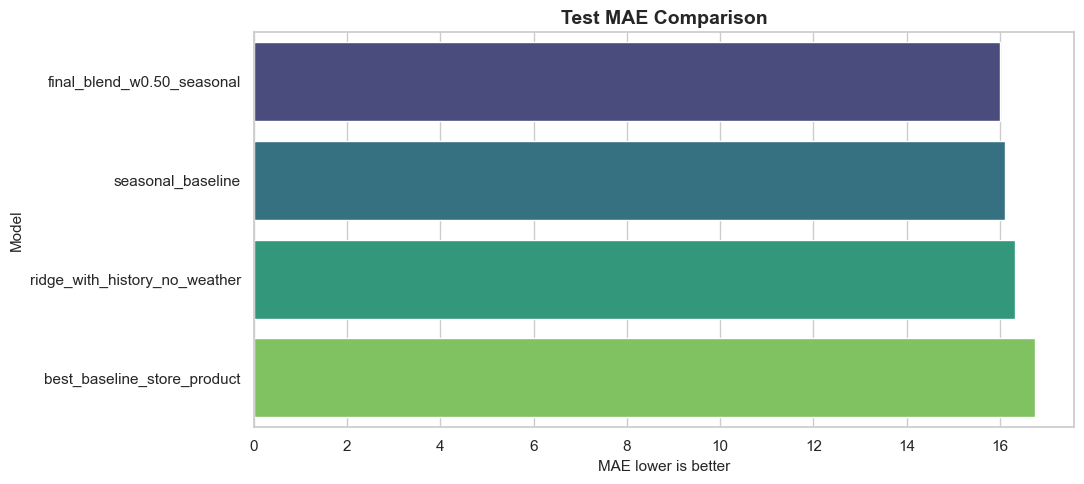

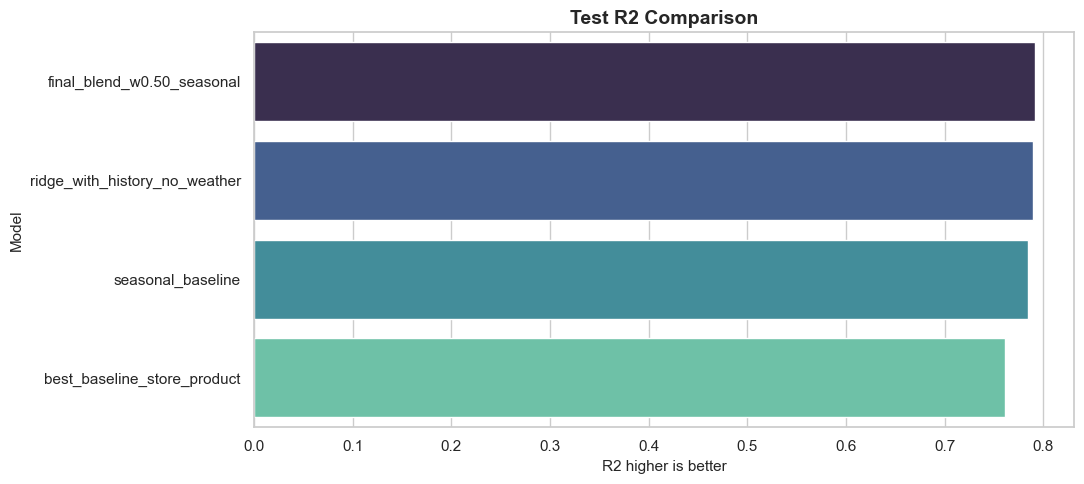

In [33]:
plot_results = final_model_results.copy()
plt.figure(figsize=(11, 5))
sns.barplot(data=plot_results, x="MAE", y="model", palette="viridis")
plt.title("Test MAE Comparison")
plt.xlabel("MAE lower is better")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_results.sort_values("R2", ascending=False), x="R2", y="model", palette="mako")
plt.title("Test R2 Comparison")
plt.xlabel("R2 higher is better")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


**Modeling insight**

Final model là blend giữa:

- Seasonal baseline: `store_product_mean × product_month_factor`
- Ridge with history: linear model có store/product/calendar/store-size/history features

Trọng số blend được chọn bằng validation trên `1998-01` đến `1998-06`, rồi test một lần trên `1998-07` đến `1998-12`. Đây là cách chọn model hợp lệ hơn so với tuning trực tiếp trên test.

Kết quả thường cho thấy final blend nhỉnh hơn từng component riêng lẻ. Tuy mức cải thiện không quá lớn, đây là điều hợp lý: dataset ngắn và mức nền `store × product_type` đã giải thích phần lớn doanh thu.


## 18. Error Analysis Của Final Model


,product_type,n,actual_revenue,pred_revenue,mae,bias,mean_actual,wape
13,Produce & Nuts,390,"45,288.8400","42,826.4200",29.5000,-6.3100,116.1300,0.0540
8,Household & Cleaning,390,"37,751.1200","34,471.4600",25.9000,-8.4100,96.8000,0.0870
15,Snacks & Sweets,390,"40,762.4100","38,095.6100",25.3600,-6.8400,104.5200,0.0650
6,Frozen Foods,390,"31,385.7100","29,136.0700",22.2000,-5.7700,80.4800,0.0720
5,Dairy & Eggs,390,"24,862.9000","23,709.8000",19.2600,-2.9600,63.7500,0.0460
11,Pantry & Condiments,390,"22,528.1400","20,723.8700",17.7100,-4.6300,57.7600,0.0800
2,Beverages,390,"21,424.1000","19,923.5100",16.8300,-3.8500,54.9300,0.0700
10,Meat & Deli,390,"17,874.9000","16,632.8500",14.4000,-3.1800,45.8300,0.0690
7,Health & Personal Care,390,"16,727.4100","15,777.3200",14.2100,-2.4400,42.8900,0.0570
4,Canned & Soup,390,"16,321.9600","16,292.5600",13.7000,-0.0800,41.8500,0.0020


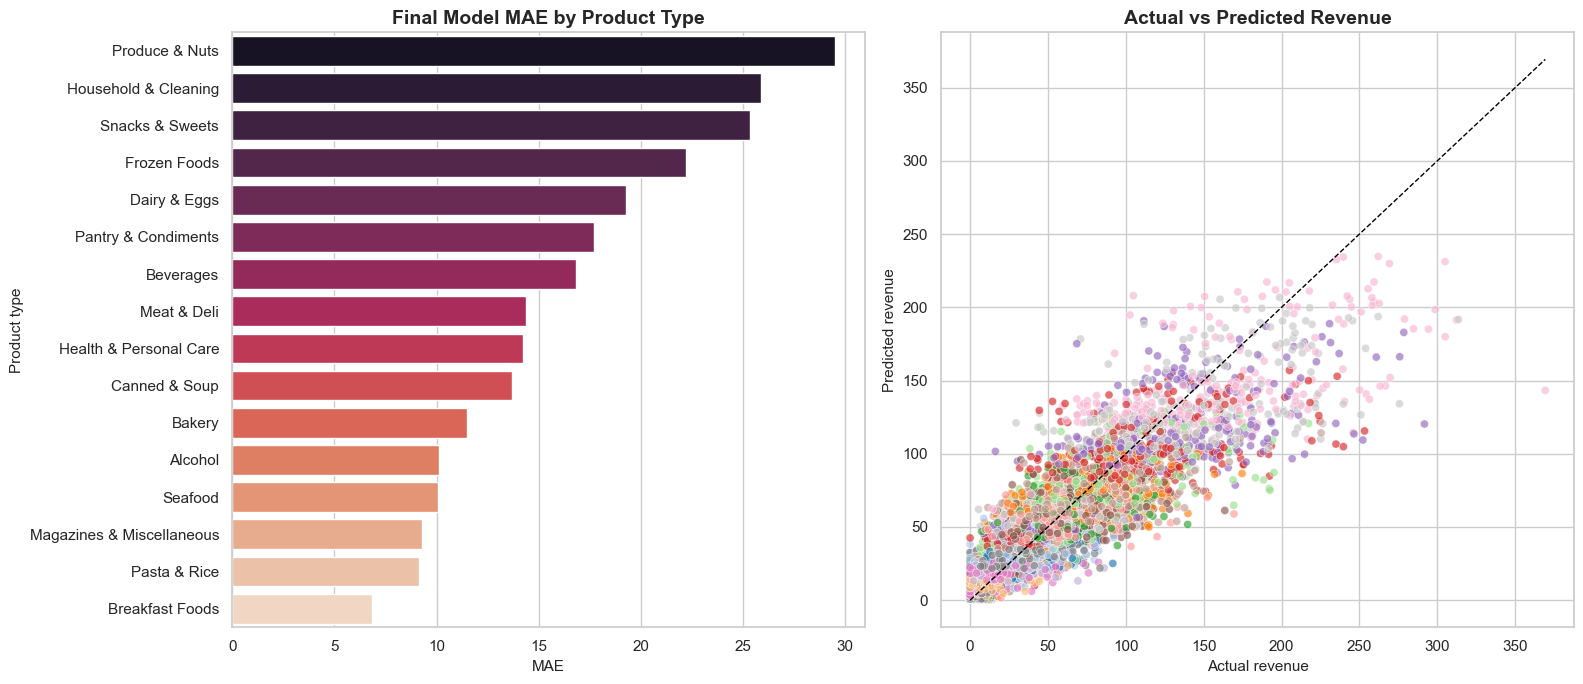

In [34]:
test_pred = test_df[key_cols + ["store_type", "store_city", "sales_region", "month", "revenue"]].copy()
test_pred["pred_revenue"] = np.clip(test_pred_blend, 0, None)
test_pred["error"] = test_pred["pred_revenue"] - test_pred["revenue"]
test_pred["abs_error"] = test_pred["error"].abs()

error_by_product = (
    test_pred.groupby("product_type")
    .agg(
        n=("revenue", "size"),
        actual_revenue=("revenue", "sum"),
        pred_revenue=("pred_revenue", "sum"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
        mean_actual=("revenue", "mean"),
    )
    .reset_index()
)
error_by_product["wape"] = (error_by_product["pred_revenue"] - error_by_product["actual_revenue"]).abs() / (error_by_product["actual_revenue"] + 1e-12)
error_by_product = error_by_product.sort_values("mae", ascending=False)

display(error_by_product.round({"actual_revenue": 2, "pred_revenue": 2, "mae": 2, "bias": 2, "mean_actual": 2, "wape": 3}))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=error_by_product, y="product_type", x="mae", palette="rocket", ax=axes[0])
axes[0].set_title("Final Model MAE by Product Type")
axes[0].set_xlabel("MAE")
axes[0].set_ylabel("Product type")

sns.scatterplot(data=test_pred, x="revenue", y="pred_revenue", hue="product_type", palette="tab20", alpha=0.65, s=35, ax=axes[1], legend=False)
max_val = max(test_pred["revenue"].max(), test_pred["pred_revenue"].max())
axes[1].plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1)
axes[1].set_title("Actual vs Predicted Revenue")
axes[1].set_xlabel("Actual revenue")
axes[1].set_ylabel("Predicted revenue")

plt.tight_layout()
plt.show()


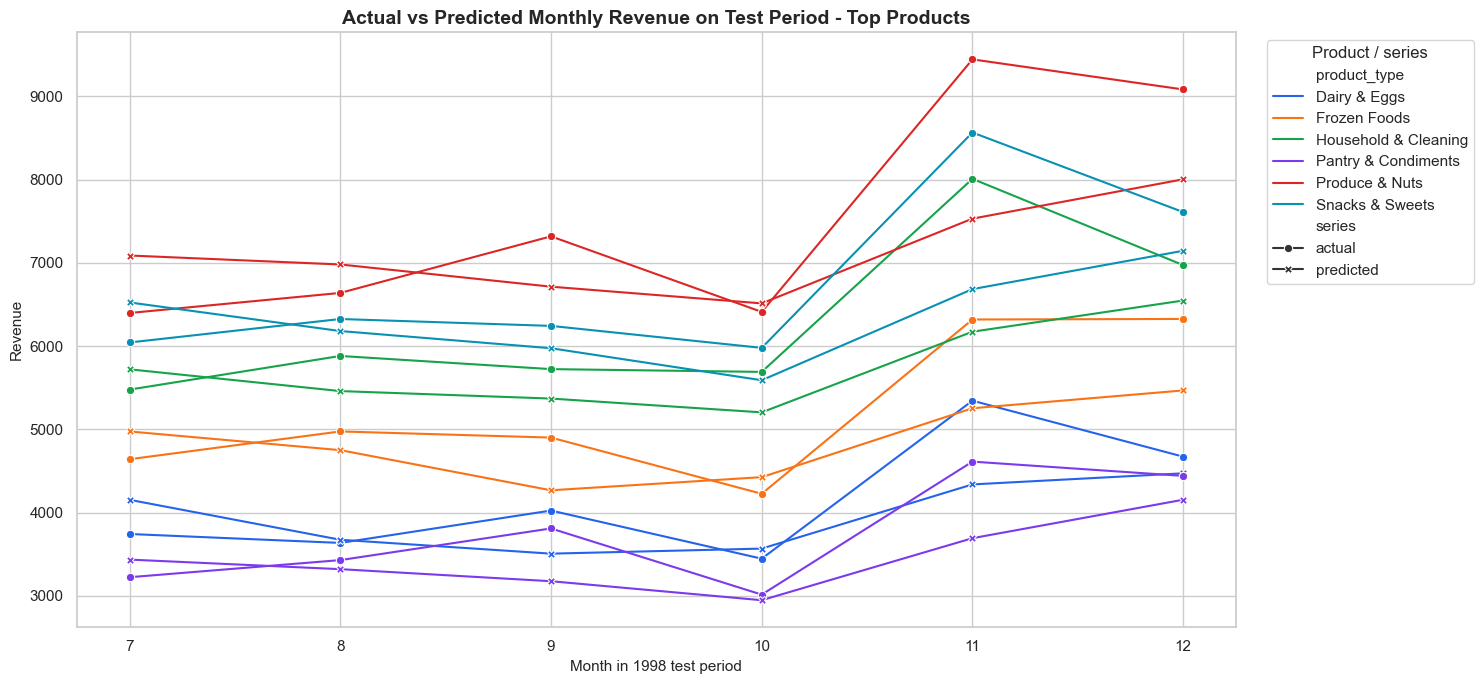

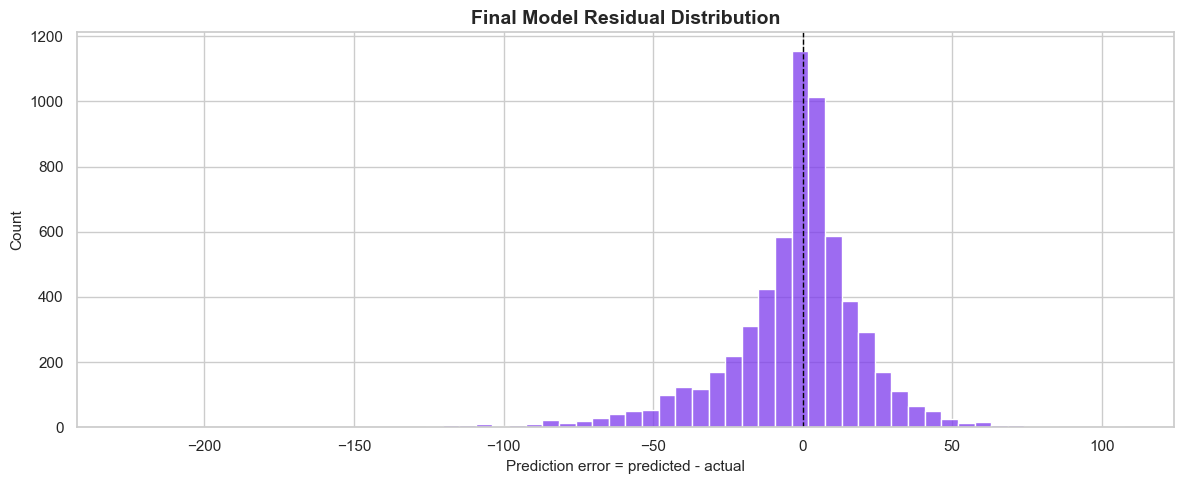

In [35]:
monthly_pred = (
    test_pred.groupby(["month", "product_type"])
    .agg(actual=("revenue", "sum"), predicted=("pred_revenue", "sum"))
    .reset_index()
)
monthly_pred_top = monthly_pred[monthly_pred["product_type"].isin(top_products)].copy()
monthly_pred_long = monthly_pred_top.melt(
    id_vars=["month", "product_type"],
    value_vars=["actual", "predicted"],
    var_name="series",
    value_name="revenue",
)

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=monthly_pred_long,
    x="month",
    y="revenue",
    hue="product_type",
    style="series",
    markers=True,
    dashes=False,
    palette=PALETTE_CONTRAST,
)
plt.title("Actual vs Predicted Monthly Revenue on Test Period - Top Products")
plt.xlabel("Month in 1998 test period")
plt.ylabel("Revenue")
plt.legend(title="Product / series", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(test_pred["error"], bins=60, color=COLOR_PURPLE)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Final Model Residual Distribution")
plt.xlabel("Prediction error = predicted - actual")
plt.tight_layout()
plt.show()


**Error analysis insight**

Các nhóm doanh thu lớn thường có MAE tuyệt đối cao hơn vì scale lớn hơn. Vì vậy khi đọc error nên nhìn cả MAE và WAPE/bias. Scatter actual-vs-predicted cho thấy model bắt tốt mức nền trung bình, nhưng vẫn khó dự báo các spike doanh thu rất cao. Đây là hạn chế tự nhiên khi dataset chỉ có 5 ngày mẫu mỗi tháng và không dùng các biến giao dịch cùng ngày.


## 19. Fit Final Model Trên Toàn Bộ Dữ Liệu Và Hàm Dự Báo Tương Lai


In [36]:
# Fit final artifacts on all available data after evaluation.
final_seasonal_artifacts = fit_seasonal_baseline(df_model)
final_ridge_artifacts = fit_ridge_numpy(df_model, numeric_base_features + numeric_history_features, categorical_features, alpha=25.0)
FINAL_SEASONAL_WEIGHT = best_weight

store_reference = (
    df_model.sort_values("transaction_date")
    .drop_duplicates("store_id", keep="last")
    .set_index("store_id")
)


def make_future_frame(future_date, store_ids=None, product_types=None):
    """Create feature rows for one future date.

    This is a one-step-ahead style frame: history features use actual data available before future_date.
    For multiple future dates, a recursive strategy is needed if later dates should use earlier predictions as lags.
    """
    future_date = pd.Timestamp(future_date)
    if store_ids is None:
        store_ids = sorted(df_model["store_id"].unique())
    if product_types is None:
        product_types = sorted(df_model["product_type"].unique())

    rows = []
    for store_id in store_ids:
        if store_id not in store_reference.index:
            raise ValueError(f"Unknown store_id: {store_id}")
        meta = store_reference.loc[store_id].copy()
        for product_type in product_types:
            row = {
                "transaction_date": future_date,
                "store_id": store_id,
                "product_type": product_type,
                "region_id": meta["region_id"],
                "store_type": meta["store_type"],
                "store_city": meta["store_city"],
                "store_state": meta["store_state"],
                "first_opened_date": meta["first_opened_date"],
                "last_remodel_date": meta["last_remodel_date"],
                "total_sqft": meta["total_sqft"],
                "grocery_sqft": meta["grocery_sqft"],
                "sales_district": meta["sales_district"],
                "sales_region": meta["sales_region"],
                "grocery_sqft_ratio": meta["grocery_sqft_ratio"],
                "year": future_date.year,
                "month": future_date.month,
                "quarter": ((future_date.month - 1) // 3) + 1,
                "day": future_date.day,
                "day_of_week": future_date.day_name(),
                "day_of_week_num": future_date.dayofweek,
                "week_of_year": int(future_date.isocalendar().week),
                "is_weekend": int(future_date.dayofweek >= 5),
                "store_age_years": (future_date - meta["first_opened_date"]).days / 365.25,
                "years_since_remodel": (future_date - meta["last_remodel_date"]).days / 365.25,
                "had_observed_transaction_row": np.nan,
                "revenue": np.nan,
            }
            rows.append(row)

    future = pd.DataFrame(rows)
    future = add_calendar_features(future)

    # Add history features manually from actual historical panel.
    hist = df_model[df_model["transaction_date"] < future_date].sort_values("transaction_date")
    feature_rows = []
    for _, row in future.iterrows():
        h = hist[(hist["store_id"] == row["store_id"]) & (hist["product_type"] == row["product_type"])]
        revenues = h["revenue"].values.astype(float)
        dates = h["transaction_date"].values

        row = row.copy()
        for lag in [1, 2, 3]:
            row[f"revenue_lag_{lag}_obs"] = revenues[-lag] if len(revenues) >= lag else np.nan
        row["revenue_roll_mean_3_obs"] = np.mean(revenues[-3:]) if len(revenues) >= 1 else np.nan
        row["revenue_roll_mean_6_obs"] = np.mean(revenues[-6:]) if len(revenues) >= 1 else np.nan
        row["revenue_roll_std_6_obs"] = np.std(revenues[-6:], ddof=1) if len(revenues) >= 2 else np.nan
        row["zero_rate_roll_6_obs"] = np.mean(revenues[-6:] == 0) if len(revenues) >= 1 else np.nan
        row["sp_expanding_mean"] = np.mean(revenues) if len(revenues) >= 1 else np.nan
        row["days_since_prev_obs"] = (future_date - pd.Timestamp(dates[-1])).days if len(dates) >= 1 else np.nan
        feature_rows.append(row)

    return pd.DataFrame(feature_rows)


def predict_future_revenue(future_date, store_ids=None, product_types=None):
    future = make_future_frame(future_date, store_ids=store_ids, product_types=product_types)
    pred_seasonal = predict_seasonal_baseline(final_seasonal_artifacts, future)
    pred_ridge = predict_ridge_numpy(final_ridge_artifacts, future)
    future["pred_revenue_seasonal"] = pred_seasonal
    future["pred_revenue_ridge"] = pred_ridge
    future["pred_revenue_final"] = FINAL_SEASONAL_WEIGHT * pred_seasonal + (1 - FINAL_SEASONAL_WEIGHT) * pred_ridge
    return future.sort_values("pred_revenue_final", ascending=False)

# Demo: predict a few product types for a future date.
demo_future = predict_future_revenue(
    "1999-01-05",
    store_ids=[13, 17, 14],
    product_types=["Produce & Nuts", "Snacks & Sweets", "Household & Cleaning", "Breakfast Foods"],
)

display(demo_future[[
    "transaction_date", "store_id", "store_city", "store_type", "product_type",
    "revenue_lag_1_obs", "revenue_roll_mean_6_obs", "sp_expanding_mean",
    "pred_revenue_seasonal", "pred_revenue_ridge", "pred_revenue_final",
]].round(2))


,transaction_date,store_id,store_city,store_type,product_type,revenue_lag_1_obs,revenue_roll_mean_6_obs,sp_expanding_mean,pred_revenue_seasonal,pred_revenue_ridge,pred_revenue_final
0,1999-01-05,13,Salem,Deluxe Supermarket,Produce & Nuts,269.2300,261.7400,210.0600,204.9700,218.3500,211.6600
4,1999-01-05,17,Tacoma,Deluxe Supermarket,Produce & Nuts,176.1600,206.4600,189.7200,185.1300,190.4000,187.7600
5,1999-01-05,17,Tacoma,Deluxe Supermarket,Snacks & Sweets,313.6000,234.3100,169.1600,165.2800,196.2500,180.7600
1,1999-01-05,13,Salem,Deluxe Supermarket,Snacks & Sweets,160.5200,186.9100,181.5700,177.4100,181.1500,179.2800
2,1999-01-05,13,Salem,Deluxe Supermarket,Household & Cleaning,124.6100,194.4700,166.3400,162.8000,158.2000,160.5000
6,1999-01-05,17,Tacoma,Deluxe Supermarket,Household & Cleaning,136.6800,159.0800,152.7200,149.4700,151.9100,150.6900
7,1999-01-05,17,Tacoma,Deluxe Supermarket,Breakfast Foods,15.0000,20.9400,16.1100,15.2300,17.9600,16.5900
3,1999-01-05,13,Salem,Deluxe Supermarket,Breakfast Foods,12.9600,23.6800,17.1400,16.2000,14.1600,15.1800
8,1999-01-05,14,San Francisco,Small Grocery,Produce & Nuts,13.7200,15.6800,11.5000,11.2200,17.2100,14.2100
9,1999-01-05,14,San Francisco,Small Grocery,Snacks & Sweets,23.7600,14.4400,9.8400,9.6100,14.8300,12.2200


**Cách dùng forecast function**

`predict_future_revenue(date, store_ids, product_types)` tạo feature cho ngày tương lai và trả về dự báo doanh thu. Model cuối không cần weather forecast. Tuy nhiên cần nhớ:

- Đây là dự báo một bước dựa trên lịch sử thật trước ngày dự báo.
- Nếu muốn dự báo nhiều ngày tương lai liên tiếp, cần quyết định có dùng prediction của ngày trước làm lag cho ngày sau hay không.
- Vì dữ liệu train chỉ là sample 5 ngày/tháng/store, dự báo cho ngày tương lai bất kỳ là extrapolation từ cơ chế sample hiện có.


# 20. Kết Luận Tổng Hợp

Notebook đã đi từ hiểu dữ liệu đến mô hình dự báo theo đúng framing của dataset Maven, nhưng điểm quan trọng nhất là phải hiểu giới hạn và quy luật riêng của dữ liệu:

1. Dataset là panel `store_id × product_type × transaction_date`, nhưng daily không liên tục. Mỗi store chỉ có `5 observed days/tháng`, nên không được fill các ngày store không được lấy mẫu thành 0.
2. Trong một observed store-day, product type thiếu được xem là 0 revenue. Sau bước này panel có đủ `observed store-day × 16 product types`.
3. `product_type` là trung tâm phân tích. `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`, `Frozen Foods` chiếm phần lớn revenue; `Breakfast Foods`, `Pasta & Rice`, `Magazines & Miscellaneous` là nhóm sparse/long-tail hơn.
4. Store type tạo khác biệt rất lớn. `Small Grocery` có zero-rate khoảng 33% và nhiều product type sparse, nên model phải học store/store_type/product structure.
5. Store-product baseline rất mạnh. Top 20 cặp store-product chiếm gần 30% revenue, giải thích vì sao `store_product_mean` là baseline cạnh tranh.
6. Seasonality Q4 có thật và xuất hiện ở hầu hết product type, nhưng mức tăng không đều. Các nhóm như `Canned & Soup`, `Beverages`, `Pasta & Rice`, `Bakery` có Q4 lift mạnh hơn, còn `Magazines & Miscellaneous` tăng yếu hơn.
7. Weekend effect không phải signal chính. Một số nhóm như `Breakfast Foods` có weekend lift, nhưng nhiều product type có CI cắt 0 hoặc lift âm nhẹ.
8. Weather/rain không có bằng chứng mạnh sau khi normalize theo store-product-year. Vì vậy no-weather model là lựa chọn thực dụng hơn nếu không có weather forecast tương lai.
9. Test period cao hơn train ở hầu hết product type, nên mean baseline dễ underpredict. Cần history gần nhất, trend/calendar và seasonal factor.
10. Lag/history có signal, nhưng yếu hơn M5 vì dữ liệu chỉ lấy mẫu 5 ngày/tháng/store. Nhóm volume cao có lag correlation tốt hơn nhóm sparse.

Kết quả model cuối vẫn giữ logic:

- Seasonal baseline nắm product-month seasonality.
- Ridge history no-weather nắm store/product/calendar/history.
- Final blend được chọn bằng validation, không tune trực tiếp trên test.

Kết luận modeling:

> Final blend giữa seasonal baseline và Ridge history no-weather là lựa chọn hợp lý nhất hiện tại: đơn giản, tránh leakage, không phụ thuộc weather forecast, và bám đúng các quy luật quan trọng nhất trong data: store-product baseline, product-specific Q4 seasonality, store type sparsity, drift và history signal.

Hướng phát triển tiếp theo:

- Tạo feature riêng cho `store_type × product_type` zero-rate/history.
- Tách đánh giá model theo nhóm volume cao và nhóm sparse.
- Nếu có thêm nhiều năm, kiểm định seasonality chắc hơn.
- Nếu có transaction-level hoặc inventory/assortment data, có thể phân biệt rõ hơn giữa không bán vì không có nhu cầu và không bán vì không có hàng/không assortment.
